## Threshold 4Å Re-baseline

Re-run feature extraction and correlation analysis using RMSD threshold = 4.0Å (previously 2.0Å).

**Top-feature selection:** For each of the 120 SAE features, we compute the Spearman
correlation between that feature's activation values and RMSD across all test-set poses.
The top 20 are the features with the **highest positive Spearman correlation with RMSD** —
i.e. features that tend to fire more as pose quality worsens (continuous relationship).
This is a different lens than the logistic regression below, which optimises for binary classification.

**Output files:**
- `processed_data/metadata_rmsd4.csv`
- `processed_data/features_for_paper.npz` — test-set activations for k=3, 8, 15
- `processed_data/top_features_k3/8/15.csv`
- `processed_data/roc_auc_comparison.png`

In [1]:
import warnings
import torch
import numpy as np
import pandas as pd
import sys
import os
from scipy.stats import spearmanr, ConstantInputWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=ConstantInputWarning)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data_processor import load_processed_data
from src.model import TopKSAE

DATA_DIR       = '/Users/bridget/Desktop/projects/laloo-sae/processed_data'
OUT_DIR        = os.path.join(PROJECT_ROOT, 'output', '4A')
os.makedirs(OUT_DIR, exist_ok=True)
MODEL_DIR      = os.path.expanduser('~/Desktop/projects/laloo-sae/models/07_30_26')
RMSD_THRESHOLD = 4.0
K_VALUES       = [3, 8, 15, 20, 30]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Data dir:   {DATA_DIR}')
print(f'Output dir: {OUT_DIR}')
print(f'Model dir:  {MODEL_DIR}')

Device: cpu
Data dir:   /Users/bridget/Desktop/projects/laloo-sae/processed_data
Output dir: /Users/bridget/Desktop/projects/laloo-sae/output/4A
Model dir:  /Users/bridget/Desktop/projects/laloo-sae/models/07_30_26


### 1. Load data and update quality labels

In [2]:
latents_normalized, metadata, stats = load_processed_data(DATA_DIR)
print(f'Latents shape: {latents_normalized.shape}')
print(f'Metadata shape: {metadata.shape}')
metadata.head()

Loaded 435,069 samples from /Users/bridget/Desktop/projects/laloo-sae/processed_data
Latents shape: (435069, 30)
Metadata shape: (435069, 6)


,case_id,sample_idx,rmsd,energy,generation,global_idx
0,afab_2nnq_afab_3fr4,0,2.385954,-5425.862544,15,0
1,afab_2nnq_afab_3fr4,1,3.430689,10000.000000,15,1
2,afab_2nnq_afab_3fr4,2,3.147245,-5404.352427,8,2
3,afab_2nnq_afab_3fr4,3,2.383592,-5421.452032,14,3
4,afab_2nnq_afab_3fr4,4,3.503210,-5409.776425,8,4


In [3]:
metadata_4 = metadata.copy()
metadata_4['good_pose'] = metadata_4['rmsd'] < RMSD_THRESHOLD

n_good = metadata_4['good_pose'].sum()
n_bad  = (~metadata_4['good_pose']).sum()
print(f'RMSD threshold: {RMSD_THRESHOLD}Å')
print(f'  Good poses (RMSD < {RMSD_THRESHOLD}Å): {n_good:,} ({n_good/len(metadata_4)*100:.1f}%)')
print(f'  Bad  poses (RMSD >= {RMSD_THRESHOLD}Å): {n_bad:,} ({n_bad/len(metadata_4)*100:.1f}%)')

out_path = os.path.join(OUT_DIR, 'metadata.csv')
metadata_4.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

RMSD threshold: 4.0Å
  Good poses (RMSD < 4.0Å): 156,243 (35.9%)
  Bad  poses (RMSD >= 4.0Å): 278,826 (64.1%)



Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/metadata.csv


### 2. Load train / test splits

In [4]:
splits    = np.load(os.path.join(DATA_DIR, 'splits.npz'), allow_pickle=True)
train_idx = splits['train_idx']
val_idx   = splits['val_idx']
test_idx  = splits['test_idx']
print(f'Train: {len(train_idx):,}  |  Val: {len(val_idx):,}  |  Test: {len(test_idx):,}')

# Binary labels: 1 = bad pose, 0 = good pose
y_train = (~metadata_4['good_pose'].values[train_idx]).astype(int)
y_val   = (~metadata_4['good_pose'].values[val_idx]).astype(int)
y_test  = (~metadata_4['good_pose'].values[test_idx]).astype(int)

# Raw latents (30-dim) -- baseline for logistic regression
X_raw_train = latents_normalized[train_idx]
X_raw_val   = latents_normalized[val_idx]
X_raw_test  = latents_normalized[test_idx]

# Metadata for test-set evaluation (held out -- never used to pick features/thresholds/combos)
metadata_test = metadata_4.iloc[test_idx].reset_index(drop=True)
rmsd_test     = metadata_test['rmsd'].values
energy_test   = metadata_test['energy'].values
good_mask     = metadata_test['good_pose'].values

# Metadata for train-set feature/threshold selection (section 5/7 select on this, not on test)
metadata_train  = metadata_4.iloc[train_idx].reset_index(drop=True)
rmsd_train      = metadata_train['rmsd'].values
energy_train    = metadata_train['energy'].values
good_mask_train = metadata_train['good_pose'].values

# Metadata for validation-set combo/candidate selection (sections 11/12 select on this,
# not on test -- test is touched exactly once, for the final reported numbers)
metadata_val  = metadata_4.iloc[val_idx].reset_index(drop=True)
rmsd_val      = metadata_val['rmsd'].values
energy_val    = metadata_val['energy'].values
good_mask_val = metadata_val['good_pose'].values

print(f'Test good: {good_mask.sum():,} ({good_mask.mean()*100:.1f}%)')
print(f'Test bad:  {(~good_mask).sum():,} ({(~good_mask).mean()*100:.1f}%)')
print(f'Val good:  {good_mask_val.sum():,} ({good_mask_val.mean()*100:.1f}%)')
print(f'Val bad:   {(~good_mask_val).sum():,} ({(~good_mask_val).mean()*100:.1f}%)')


Train: 294,851  |  Val: 71,604  |  Test: 68,614
Test good: 25,127 (36.6%)
Test bad:  43,487 (63.4%)
Val good:  21,135 (29.5%)
Val bad:   50,469 (70.5%)


### 3. Load SAE models (k = 3, 8, 15)

In [5]:
summary = torch.load(
    os.path.join(MODEL_DIR, 'training_summary.pkl'),
    map_location='cpu', weights_only=False
)

trained_models = {}
for k in K_VALUES:
    run_stats    = summary[k]
    best_run_idx = int(np.argmin([r['best_val_loss'] for r in run_stats]))
    filepath     = os.path.join(MODEL_DIR, f'topksae_k{k}_run{best_run_idx}.pt')
    model = TopKSAE(input_dim=30, hidden_dim=120, k=k, auxk=12,
                    batch_size=256, dead_steps_threshold=2000).to(device)
    model.load_state_dict(
        torch.load(filepath, map_location=device, weights_only=False)
    )
    model.eval()
    trained_models[k] = model
    print(f'  [+] k={k}: run {best_run_idx}  '
          f'(val_loss={run_stats[best_run_idx]["best_val_loss"]:.4f})')

print(f'\nLoaded {len(trained_models)} models.')

  [+] k=3: run 2  (val_loss=0.3882)
  [+] k=8: run 0  (val_loss=0.2088)
  [+] k=15: run 3  (val_loss=0.0535)
  [+] k=20: run 3  (val_loss=0.0139)
  [+] k=30: run 3  (val_loss=0.0001)

Loaded 5 models.


### 4. Extract features (test + train) and save

In [6]:
BATCH_SIZE = 2048

def extract_activations(model, latents_np, batch_size=BATCH_SIZE):
    """Run model.get_acts() in batches. Input: numpy [N, 30]. Returns numpy [N, 120]."""
    all_acts = []
    for start in range(0, latents_np.shape[0], batch_size):
        batch = torch.tensor(latents_np[start:start + batch_size],
                             dtype=torch.float32, device=device)
        all_acts.append(model.get_acts(batch).cpu().numpy())
    return np.vstack(all_acts)


features_test  = {}   # correlation analysis + logistic regression eval
features_train = {}   # threshold fitting
features_val   = {}   # combo/candidate SELECTION (sections 11/12) -- held out from test

for k in K_VALUES:
    print(f'k={k}:', end=' ', flush=True)
    features_test[k]  = extract_activations(trained_models[k], X_raw_test)
    print(f'test={features_test[k].shape}', end='  ', flush=True)
    features_train[k] = extract_activations(trained_models[k], X_raw_train)
    print(f'train={features_train[k].shape}', end='  ', flush=True)
    features_val[k]   = extract_activations(trained_models[k], X_raw_val)
    print(f'val={features_val[k].shape}  '
          f'zeros={(features_test[k]==0).mean()*100:.1f}%')

feat_path = os.path.join(OUT_DIR, 'features_for_paper.npz')
np.savez_compressed(
    feat_path,
    k3=features_test[3],
    k8=features_test[8],
    k15=features_test[15],
    test_idx=test_idx,
)
print(f'\nSaved: {feat_path}')


k=3: 

test=(68614, 120)  

train=(294851, 120)  

val=(71604, 120)  zeros=97.5%
k=8: 

test=(68614, 120)  

...

val=(71604, 120)  zeros=83.3%
k=30: 

test=(68614, 120)  

train=(294851, 120)  

val=(71604, 120)  zeros=75.0%



Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/features_for_paper.npz


### 5. Compute correlations and activation rates → top-feature CSVs

In [7]:
def compute_feature_stats(acts, acts_train, y_train, rmsd, energy, good_mask, top_n=20):
    """
    For each feature column in acts [N, 120]:
      corr_rmsd              Spearman correlation with continuous RMSD
      corr_energy            Spearman correlation with energy
      activation_rate        fraction of poses where feature > 0
      good/bad_activation_rate  activation rate split by 4Å label
      probe_weight           coefficient from L1 logistic regression (bad-pose probe)
      probe_rank             rank by probe_weight (1 = most discriminative)

    `acts`/`rmsd`/`energy`/`good_mask` are the split whose correlations get reported
    (and, when it's the train split, used to pick top_spearman below — see call site).
    `acts_train`/`y_train` always come from the train split; the L1 probe is fit on
    train regardless of which split `acts` is, so probe_weight/probe_rank are never
    fit on data being evaluated.

    Top features = 20 highest positive corr_rmsd (Spearman ranking).
    Probe ranking is included as a second, multivariate lens:
      - Spearman: univariate, continuous RMSD relationship per feature
      - L1 probe: multivariate, jointly discriminative after penalising redundancy
    """
    # Fit L1 probe on train activations
    probe = LogisticRegression(
        penalty='l1', solver='saga', max_iter=2000,
        class_weight='balanced', random_state=42
    )
    # y_train is 1 = bad pose, 0 = good pose
    probe.fit(acts_train, y_train)
    weights = probe.coef_[0]                         # shape [120]
    # rank: feature with highest weight = rank 1
    probe_ranks = len(weights) - np.argsort(np.argsort(weights))

    records = []
    for feat_idx in range(acts.shape[1]):
        v              = acts[:, feat_idx]
        corr_r,   _    = spearmanr(v, rmsd)
        corr_e,   _    = spearmanr(v, energy)
        active         = v > 0
        records.append({
            'feature':              feat_idx,
            'corr_rmsd':            corr_r,
            'corr_energy':          corr_e,
            'activation_rate':      active.mean(),
            'good_activation_rate': active[good_mask].mean()  if good_mask.sum()  > 0 else float('nan'),
            'bad_activation_rate':  active[~good_mask].mean() if (~good_mask).sum() > 0 else float('nan'),
            'probe_weight':         weights[feat_idx],
            'probe_rank':           int(probe_ranks[feat_idx]),
        })
    df  = pd.DataFrame(records)
    top = df.nlargest(top_n, 'corr_rmsd').reset_index(drop=True)
    return df, top, probe


# TRAIN-computed stats: this is what actually selects top_spearman (section 7) — the
# probe is fit on train either way, so this call additionally computes corr_rmsd on
# train, keeping feature *selection* fully out of the test set.
train_feature_dfs = {}
# TEST-computed stats: reported/plotted for descriptive purposes only (e.g. "does this
# train-selected feature's correlation hold up on held-out data?") — never used to pick
# which features or thresholds get used.
all_feature_dfs = {}
probes = {}
for k in K_VALUES:
    print(f'\n--- k={k} ---')
    train_df, _, probe = compute_feature_stats(
        features_train[k], features_train[k], y_train,
        rmsd_train, energy_train, good_mask_train, top_n=20
    )
    train_feature_dfs[k] = train_df
    probes[k] = probe

    all_df, _, _ = compute_feature_stats(
        features_test[k], features_train[k], y_train,
        rmsd_test, energy_test, good_mask, top_n=20
    )
    all_feature_dfs[k] = all_df

    # Top 20 by TRAIN corr_rmsd (the actual selection), reported alongside each
    # feature's TEST corr_rmsd so we can see whether it generalizes.
    top_df = train_df.nlargest(20, 'corr_rmsd')[['feature', 'corr_rmsd', 'probe_weight', 'probe_rank']] \
                      .rename(columns={'corr_rmsd': 'corr_rmsd_train'}) \
                      .reset_index(drop=True)
    top_df = top_df.merge(
        all_df[['feature', 'corr_rmsd', 'activation_rate', 'good_activation_rate', 'bad_activation_rate']]
               .rename(columns={'corr_rmsd': 'corr_rmsd_test'}),
        on='feature', how='left'
    )

    csv_path = os.path.join(OUT_DIR, f'top_features_k{k}.csv')
    top_df.to_csv(csv_path, index=False)
    print(f'Saved: {csv_path}')
    print(top_df[['feature', 'corr_rmsd_train', 'corr_rmsd_test', 'probe_weight', 'probe_rank',
                  'activation_rate', 'good_activation_rate', 'bad_activation_rate']]
          .to_string(index=False, float_format='{:.4f}'.format))

    # Show top 5 by probe weight for comparison (probe itself is train-fit already)
    top_probe = train_df.nlargest(5, 'probe_weight')[['feature', 'probe_weight', 'probe_rank', 'corr_rmsd']]
    print(f'\n  Top 5 by probe weight (k={k}, train):')
    print(top_probe.to_string(index=False, float_format='{:.4f}'.format))


--- k=3 ---


Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/top_features_k3.csv
 feature  corr_rmsd_train  corr_rmsd_test  probe_weight  probe_rank  activation_rate  good_activation_rate  bad_activation_rate
       6           0.1939             NaN        1.6298           1           0.0000                0.0000               0.0000
      24           0.1816          0.0088        0.5306           8           0.0002                0.0000               0.0003
      66           0.1747          0.1117        0.4132          12           0.0135                0.0037               0.0191
     109           0.1362         -0.0002        0.7302           5           0.0000                0.0000               0.0000
      43           0.1292         -0.1702       -0.0466          70           0.0418                0.0946               0.0113
      68           0.1195          0.0035        0.8894           3           0.0000                0.0000               0.0000
      32           0.1126

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/top_features_k8.csv
 feature  corr_rmsd_train  corr_rmsd_test  probe_weight  probe_rank  activation_rate  good_activation_rate  bad_activation_rate
      51           0.2559          0.0389        1.2250           2           0.0104                0.0054               0.0132
      50           0.1740          0.0189        0.6632           6           0.0052                0.0037               0.0061
     100           0.1652          0.1120        0.6707           5           0.0140                0.0037               0.0199
      84           0.1551          0.0386       -0.1558          83           0.0121                0.0029               0.0173
      36           0.1298          0.0451       -0.0556          63           0.0525                0.0431               0.0580
     118           0.1083         -0.0127        0.5152          11           0.0011                0.0016               0.0009
      46           0.1051

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/top_features_k15.csv
 feature  corr_rmsd_train  corr_rmsd_test  probe_weight  probe_rank  activation_rate  good_activation_rate  bad_activation_rate
     119           0.2311          0.0037        2.8339          10           0.0011                0.0010               0.0011
     101           0.1738          0.0571        0.2991          36           0.1346                0.0371               0.1909
     110           0.1671             NaN        0.2665          38           0.0000                0.0000               0.0000
      23           0.1061         -0.0385        0.4429          35           0.0215                0.0274               0.0180
     114           0.1045          0.0799       -0.0268          66           0.0935                0.0551               0.1157
     117           0.0992          0.0125        3.4282           4           0.0002                0.0000               0.0004
     103           0.091

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/top_features_k20.csv
 feature  corr_rmsd_train  corr_rmsd_test  probe_weight  probe_rank  activation_rate  good_activation_rate  bad_activation_rate
      70           0.2047         -0.0299        0.1699          38           0.1895                0.1613               0.2059
      60           0.1265          0.1170        0.3045          33           0.4208                0.2564               0.5158
      32           0.1138          0.0306        0.0136          45           0.2576                0.2477               0.2633
      16           0.0996          0.0063       -0.0012          50           0.1518                0.1693               0.1417
     104           0.0798         -0.0274        0.0516          40           0.3737                0.3871               0.3660
      28           0.0769         -0.1172        0.0301          42           0.5404                0.6228               0.4928
      57           0.075

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/top_features_k30.csv
 feature  corr_rmsd_train  corr_rmsd_test  probe_weight  probe_rank  activation_rate  good_activation_rate  bad_activation_rate
       7           0.1529          0.1220        0.2118          19           0.1034                0.0508               0.1339
      17           0.1359         -0.0775        0.3700          13           0.3412                0.2856               0.3733
      76           0.1096          0.0003        0.5807           9           0.4012                0.3041               0.4573
      96           0.1016          0.0034       16.0000           2           0.0000                0.0000               0.0000
      88           0.1007         -0.0674        0.0219          30           0.4105                0.4463               0.3898
      74           0.1001         -0.1264       -0.0571          82           0.4386                0.5086               0.3982
      66           0.097

### 6. Logistic regression — auPR & ROC-AUC: SAE features vs raw latents

Fit on train split, evaluate on test split.

- **Baseline & SAE probes** both use `class_weight='balanced'`
- **SAE probes** use `penalty='l1'` (consistent with sae_all.ipynb; sparsity in feature space)
- **Baseline** uses default L2 (30-dim input, L1 less meaningful at this dimensionality)
- **auPR** is the primary metric here (better than AUC for the imbalanced 64/36 bad/good split)
- ROC-AUC included for comparison with prior results

In [8]:
# Raw latent baseline: L2, balanced
clf_raw = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0,
                              class_weight='balanced', random_state=42)
clf_raw.fit(X_raw_train, y_train)
prob_raw = clf_raw.predict_proba(X_raw_test)[:, 1]

# SAE probes: L1, balanced (consistent with sae_all.ipynb)
clf_sae = {}
for k in K_VALUES:
    clf = LogisticRegression(penalty='l1', solver='saga', max_iter=2000, C=1.0,
                              class_weight='balanced', random_state=42)
    clf.fit(features_train[k], y_train)
    clf_sae[k] = clf

representations = {'Raw latents (30-dim)': (prob_raw, X_raw_train.shape[1])}
for k in K_VALUES:
    representations[f'SAE k={k:<2} (120-dim)'] = (
        clf_sae[k].predict_proba(features_test[k])[:, 1], 120
    )

# y_test = 1 bad, 0 good. auPR and AUC score the bad-pose class.
roc_results  = {}
aupr_results = {}
print(f'{"Representation":<30}  {"auPR":>8}  {"ROC-AUC":>8}  {"n_feat":>6}')
print('-' * 60)
for name, (probs, n_feat) in representations.items():
    aupr = average_precision_score(y_test, probs)
    auc  = roc_auc_score(y_test, probs)
    aupr_results[name] = aupr
    roc_results[name]  = auc
    print(f'{name:<30}  {aupr:>8.4f}  {auc:>8.4f}  {n_feat:>6}')

Representation                      auPR   ROC-AUC  n_feat
------------------------------------------------------------
Raw latents (30-dim)              0.7697    0.7146      30
SAE k=3  (120-dim)                0.7091    0.5838     120
SAE k=8  (120-dim)                0.7188    0.6279     120
SAE k=15 (120-dim)                0.7499    0.6764     120
SAE k=20 (120-dim)                0.7498    0.6943     120
SAE k=30 (120-dim)                0.7409    0.6357     120


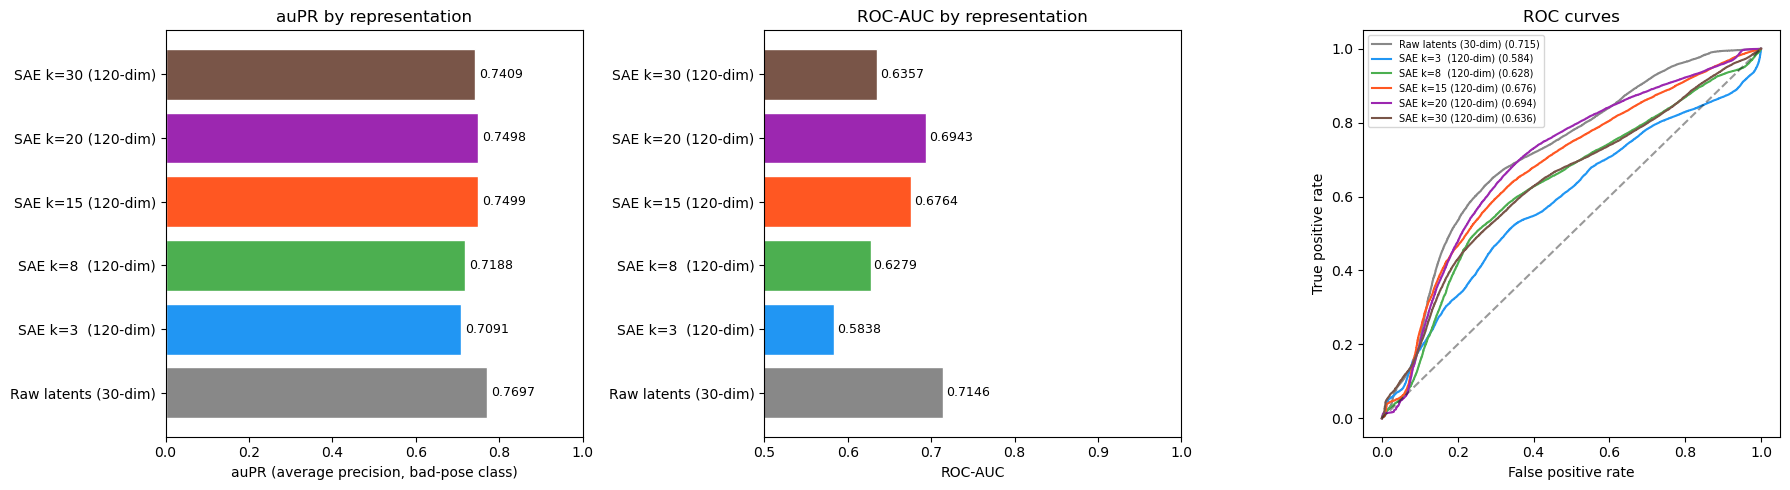

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/roc_auc_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#888888', '#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#795548'][:len(roc_results)]
names  = list(roc_results.keys())

# Left: auPR bar chart
ax = axes[0]
aupr_vals = [aupr_results[n] for n in names]
bars = ax.barh(names, aupr_vals, color=colors, edgecolor='white')
ax.set_xlim(0, 1.0)
ax.set_xlabel('auPR (average precision, bad-pose class)')
ax.set_title('auPR by representation')
for bar, v in zip(bars, aupr_vals):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)

# Middle: ROC-AUC bar chart
ax = axes[1]
auc_vals = [roc_results[n] for n in names]
bars = ax.barh(names, auc_vals, color=colors, edgecolor='white')
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('ROC-AUC')
ax.set_title('ROC-AUC by representation')
for bar, v in zip(bars, auc_vals):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)

# Right: ROC curves
ax = axes[2]
all_probs = [prob_raw] + [
    clf_sae[k].predict_proba(features_test[k])[:, 1] for k in K_VALUES
]
for name, probs, color in zip(names, all_probs, colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} ({roc_results[name]:.3f})', color=color)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves')
ax.legend(fontsize=7)

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, 'roc_auc_comparison.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

### 7. Filter threshold analysis

Top 5 bad-pose features per k by Spearman correlation with RMSD (from section 5).
For each feature: activation distribution (good vs bad, log scale) + precision/recall/F1 threshold sweep.
Best-F1 threshold used for the ablation.


Top 5 by Spearman (train): {3: [6, 24, 66, 109, 43], 8: [51, 50, 100, 84, 36], 15: [119, 101, 110, 23, 114], 20: [70, 60, 32, 16, 104], 30: [7, 17, 76, 96, 88]}
Baseline bad-pose rate (test): 0.634  (63.4%)



k=3, Feature 6 (ρ_train=0.194): train active=5,777 (2.0%)  test active=0 (0.0%)
  Train-selected thr=0.050  (train: prec=1.000 rec=0.031 F1=0.061)
  Applied to test:   prec=nan  rec=nan  F1=nan  flagged=0


/opt/schrodinger/suites2025-3/internal/lib/python3.11/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges



k=3, Feature 24 (ρ_train=0.182): train active=5,701 (1.9%)  test active=11 (0.0%)
  Train-selected thr=0.131  (train: prec=0.992 rec=0.031 F1=0.059)
  Applied to test:   prec=1.000  rec=0.000  F1=0.001  flagged=11



k=3, Feature 66 (ρ_train=0.175): train active=8,019 (2.7%)  test active=925 (1.3%)
  Train-selected thr=0.933  (train: prec=0.925 rec=0.040 F1=0.077)
  Applied to test:   prec=0.898  rec=0.019  F1=0.037  flagged=923



k=3, Feature 109 (ρ_train=0.136): train active=3,105 (1.1%)  test active=1 (0.0%)
  Train-selected thr=0.135  (train: prec=0.994 rec=0.017 F1=0.033)
  Applied to test:   prec=1.000  rec=0.000  F1=0.000  flagged=1



k=3, Feature 43 (ρ_train=0.129): train active=3,644 (1.2%)  test active=2,870 (4.2%)
  Train-selected thr=0.075  (train: prec=0.934 rec=0.018 F1=0.036)
  Applied to test:   prec=0.172  rec=0.011  F1=0.021  flagged=2,870


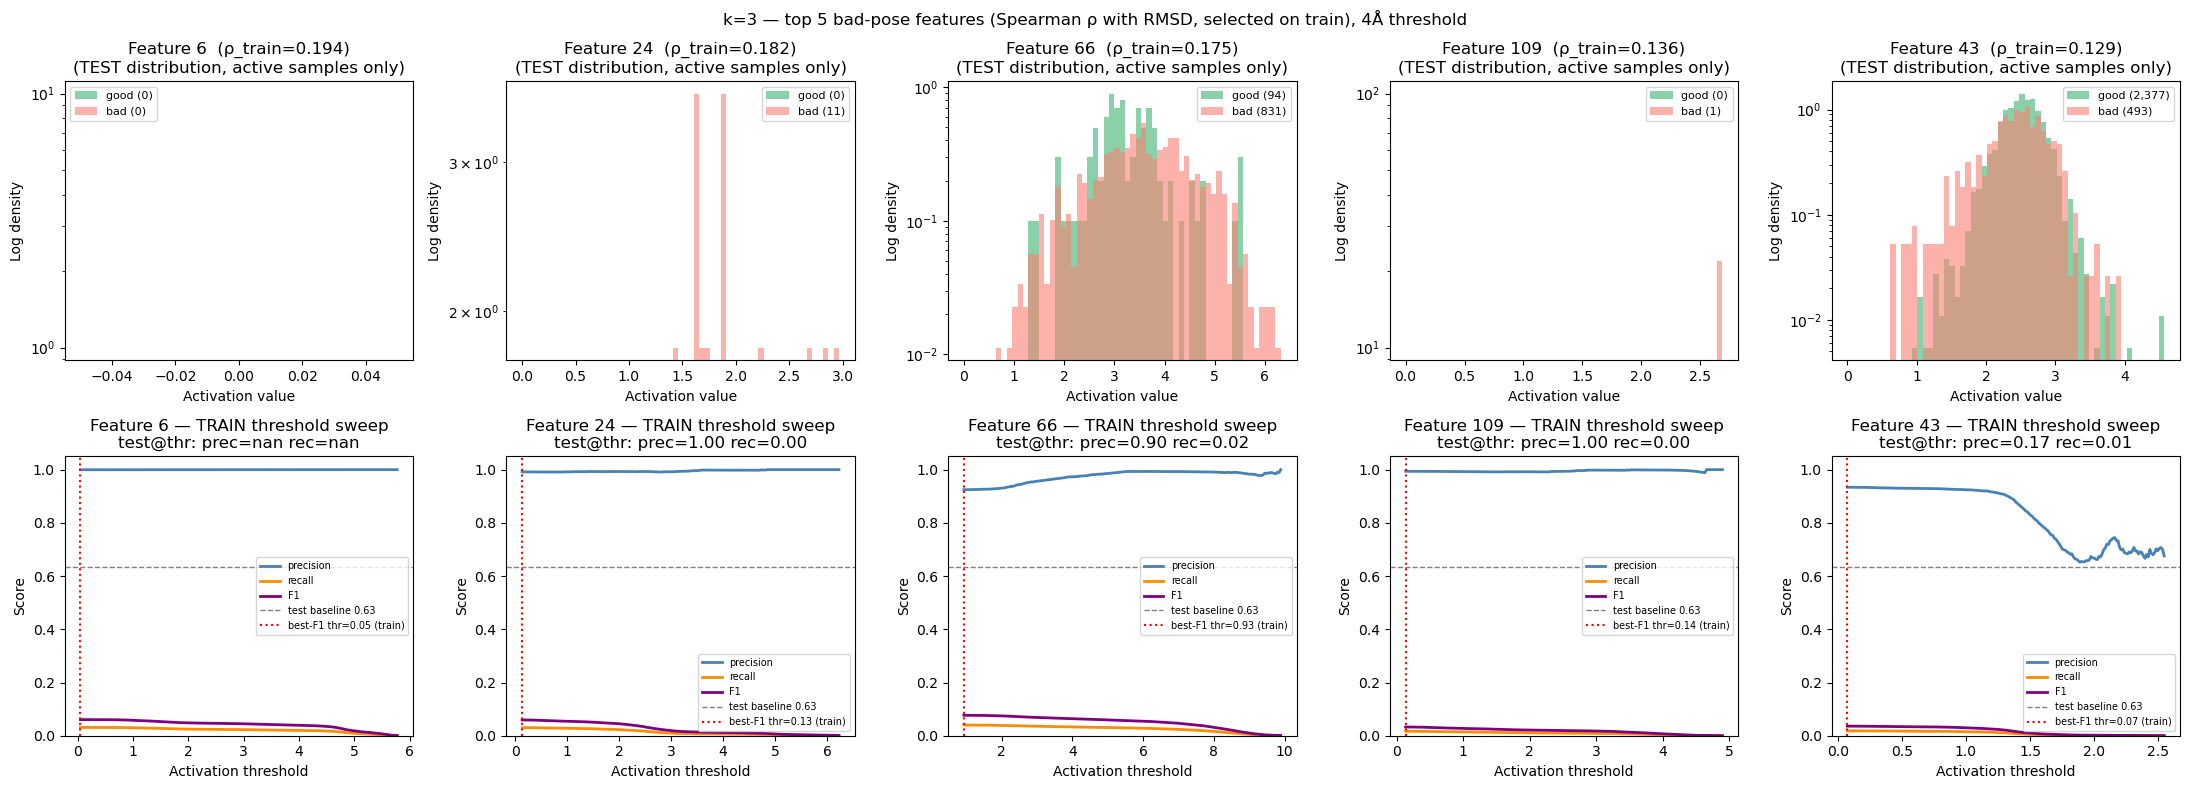


k=8, Feature 51 (ρ_train=0.256): train active=12,612 (4.3%)  test active=711 (1.0%)
  Train-selected thr=0.218  (train: prec=0.974 rec=0.066 F1=0.124)
  Applied to test:   prec=0.809  rec=0.013  F1=0.026  flagged=711



k=8, Feature 50 (ρ_train=0.174): train active=10,196 (3.5%)  test active=360 (0.5%)
  Train-selected thr=0.185  (train: prec=0.899 rec=0.050 F1=0.094)
  Applied to test:   prec=0.742  rec=0.006  F1=0.012  flagged=360



k=8, Feature 100 (ρ_train=0.165): train active=8,955 (3.0%)  test active=958 (1.4%)
  Train-selected thr=0.600  (train: prec=0.903 rec=0.044 F1=0.083)
  Applied to test:   prec=0.902  rec=0.020  F1=0.039  flagged=958



k=8, Feature 84 (ρ_train=0.155): train active=12,570 (4.3%)  test active=827 (1.2%)
  Train-selected thr=0.204  (train: prec=0.812 rec=0.055 F1=0.103)
  Applied to test:   prec=0.911  rec=0.017  F1=0.034  flagged=827



k=8, Feature 36 (ρ_train=0.130): train active=21,229 (7.2%)  test active=3,605 (5.3%)
  Train-selected thr=0.161  (train: prec=0.746 rec=0.086 F1=0.154)
  Applied to test:   prec=0.700  rec=0.058  F1=0.107  flagged=3,605


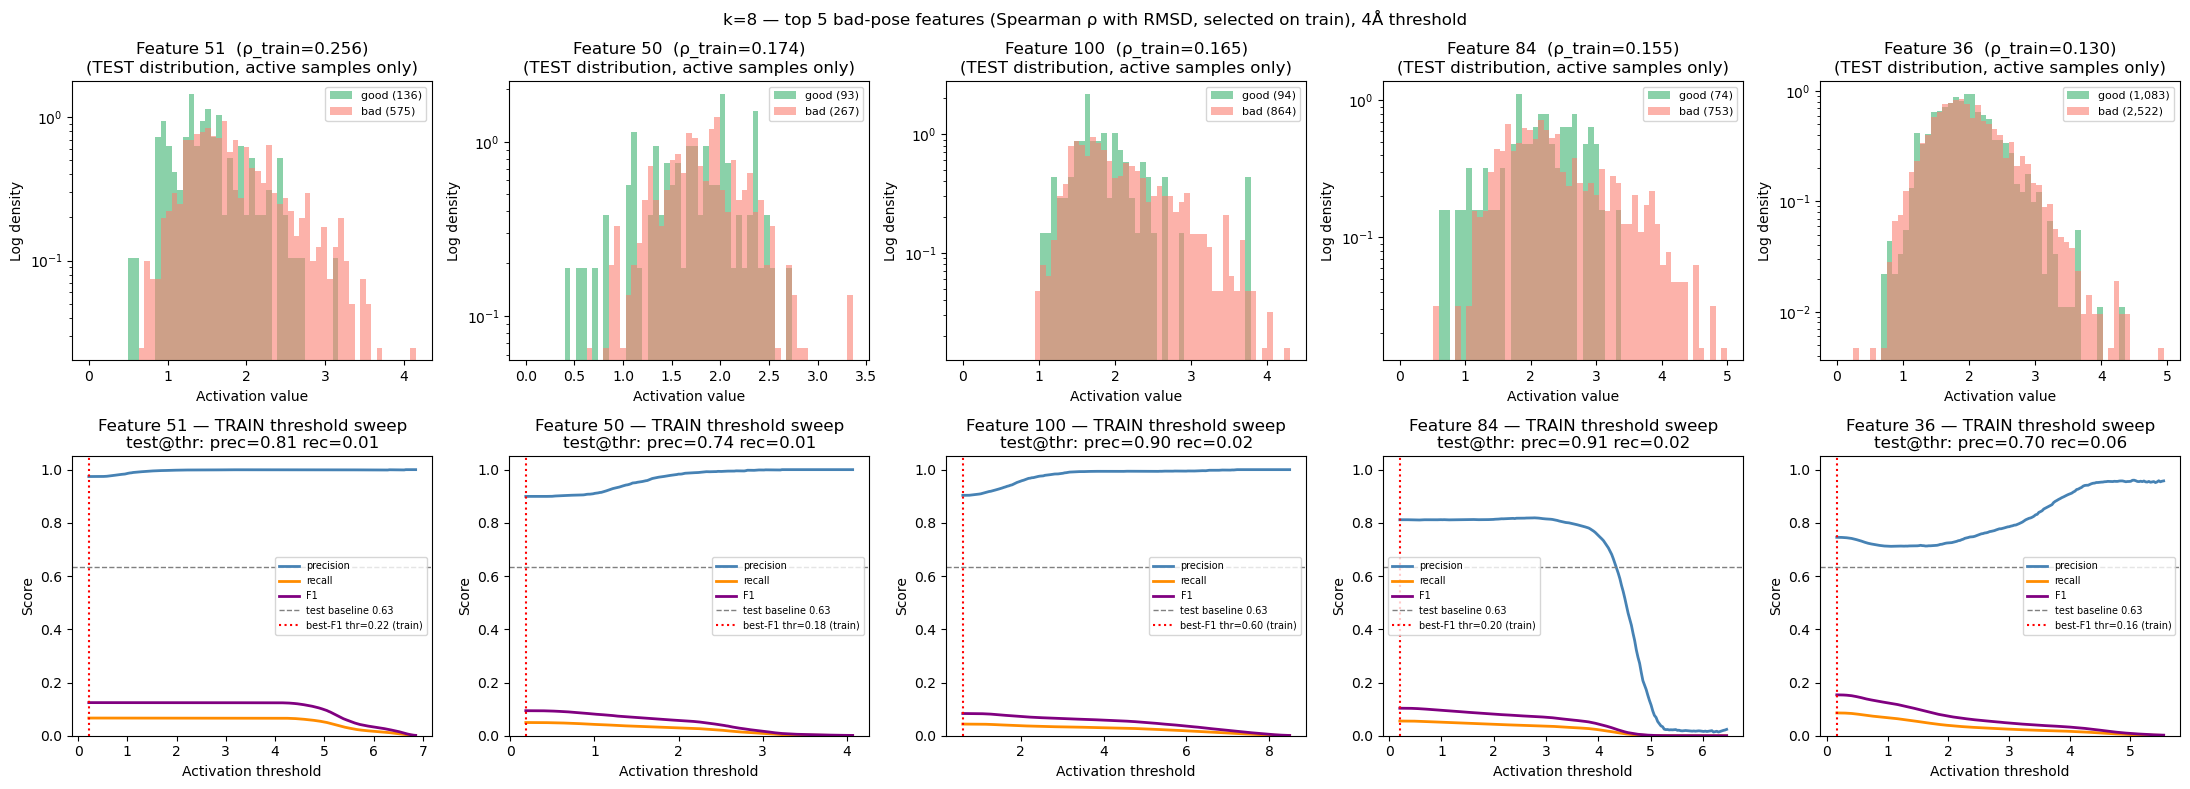


k=15, Feature 119 (ρ_train=0.231): train active=8,090 (2.7%)  test active=76 (0.1%)
  Train-selected thr=0.165  (train: prec=0.998 rec=0.044 F1=0.084)
  Applied to test:   prec=0.658  rec=0.001  F1=0.002  flagged=76



k=15, Feature 101 (ρ_train=0.174): train active=54,913 (18.6%)  test active=9,235 (13.5%)
  Train-selected thr=0.058  (train: prec=0.733 rec=0.218 F1=0.336)
  Applied to test:   prec=0.899  rec=0.191  F1=0.315  flagged=9,235



k=15, Feature 110 (ρ_train=0.167): train active=4,278 (1.5%)  test active=0 (0.0%)
  Train-selected thr=0.142  (train: prec=1.000 rec=0.023 F1=0.045)
  Applied to test:   prec=nan  rec=nan  F1=nan  flagged=0



k=15, Feature 23 (ρ_train=0.106): train active=31,769 (10.8%)  test active=1,472 (2.1%)
  Train-selected thr=0.127  (train: prec=0.738 rec=0.127 F1=0.216)
  Applied to test:   prec=0.532  rec=0.018  F1=0.035  flagged=1,472



k=15, Feature 114 (ρ_train=0.105): train active=62,466 (21.2%)  test active=6,416 (9.4%)
  Train-selected thr=0.114  (train: prec=0.679 rec=0.229 F1=0.343)
  Applied to test:   prec=0.784  rec=0.116  F1=0.202  flagged=6,416


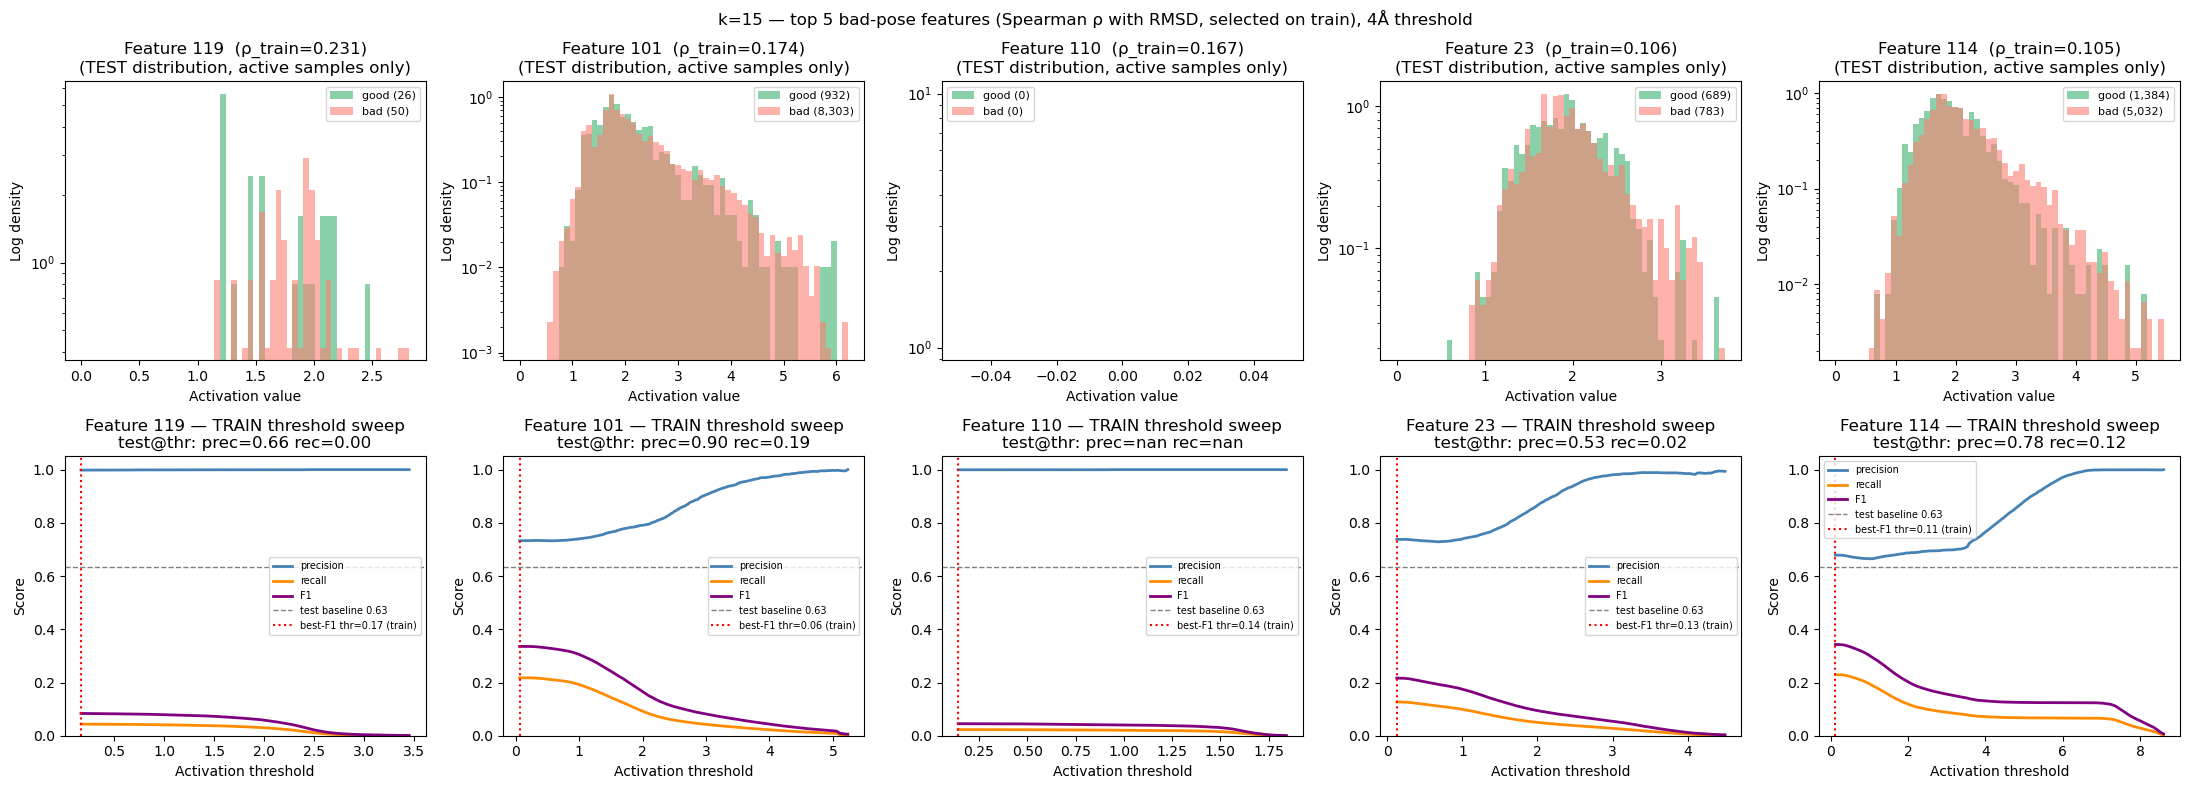


k=20, Feature 70 (ρ_train=0.205): train active=116,911 (39.7%)  test active=13,004 (19.0%)
  Train-selected thr=0.058  (train: prec=0.724 rec=0.458 F1=0.561)
  Applied to test:   prec=0.688  rec=0.206  F1=0.317  flagged=13,004



k=20, Feature 60 (ρ_train=0.126): train active=102,556 (34.8%)  test active=28,871 (42.1%)
  Train-selected thr=0.058  (train: prec=0.705 rec=0.391 F1=0.503)
  Applied to test:   prec=0.777  rec=0.516  F1=0.620  flagged=28,871



k=20, Feature 32 (ρ_train=0.114): train active=88,144 (29.9%)  test active=17,674 (25.8%)
  Train-selected thr=0.060  (train: prec=0.679 rec=0.324 F1=0.438)
  Applied to test:   prec=0.648  rec=0.263  F1=0.374  flagged=17,674



k=20, Feature 16 (ρ_train=0.100): train active=87,349 (29.6%)  test active=10,415 (15.2%)
  Train-selected thr=0.111  (train: prec=0.643 rec=0.304 F1=0.412)
  Applied to test:   prec=0.592  rec=0.142  F1=0.229  flagged=10,415



k=20, Feature 104 (ρ_train=0.080): train active=123,278 (41.8%)  test active=25,643 (37.4%)
  Train-selected thr=0.074  (train: prec=0.663 rec=0.442 F1=0.530)
  Applied to test:   prec=0.621  rec=0.366  F1=0.460  flagged=25,643


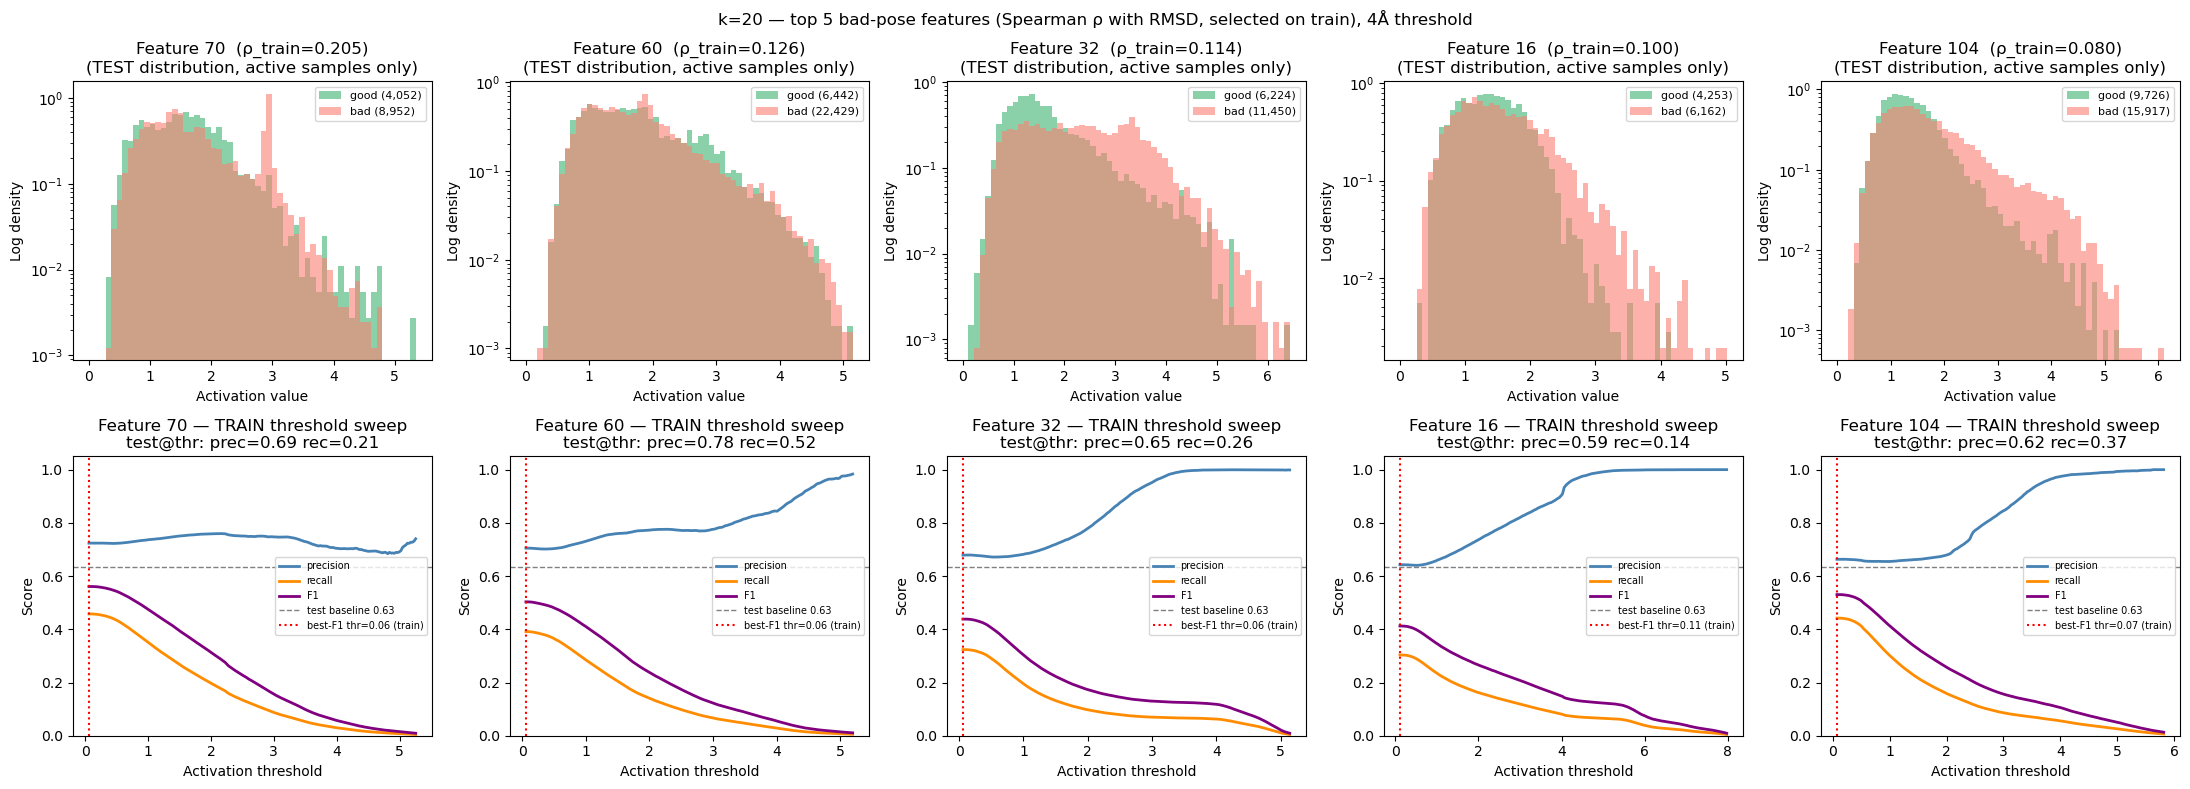


k=30, Feature 7 (ρ_train=0.153): train active=62,896 (21.3%)  test active=7,098 (10.3%)
  Train-selected thr=0.000  (train: prec=0.718 rec=0.244 F1=0.364)
  Applied to test:   prec=0.820  rec=0.134  F1=0.230  flagged=7,098



k=30, Feature 17 (ρ_train=0.136): train active=169,166 (57.4%)  test active=23,408 (34.1%)
  Train-selected thr=0.001  (train: prec=0.650 rec=0.595 F1=0.622)
  Applied to test:   prec=0.693  rec=0.373  F1=0.485  flagged=23,408



k=30, Feature 76 (ρ_train=0.110): train active=146,984 (49.9%)  test active=27,527 (40.1%)
  Train-selected thr=0.000  (train: prec=0.666 rec=0.529 F1=0.590)
  Applied to test:   prec=0.722  rec=0.457  F1=0.560  flagged=27,527



k=30, Feature 96 (ρ_train=0.102): train active=1,231 (0.4%)  test active=2 (0.0%)
  Train-selected thr=0.022  (train: prec=0.996 rec=0.007 F1=0.013)
  Applied to test:   prec=1.000  rec=0.000  F1=0.000  flagged=2



k=30, Feature 88 (ρ_train=0.101): train active=132,933 (45.1%)  test active=28,166 (41.0%)
  Train-selected thr=0.001  (train: prec=0.671 rec=0.482 F1=0.561)
  Applied to test:   prec=0.602  rec=0.390  F1=0.473  flagged=28,166


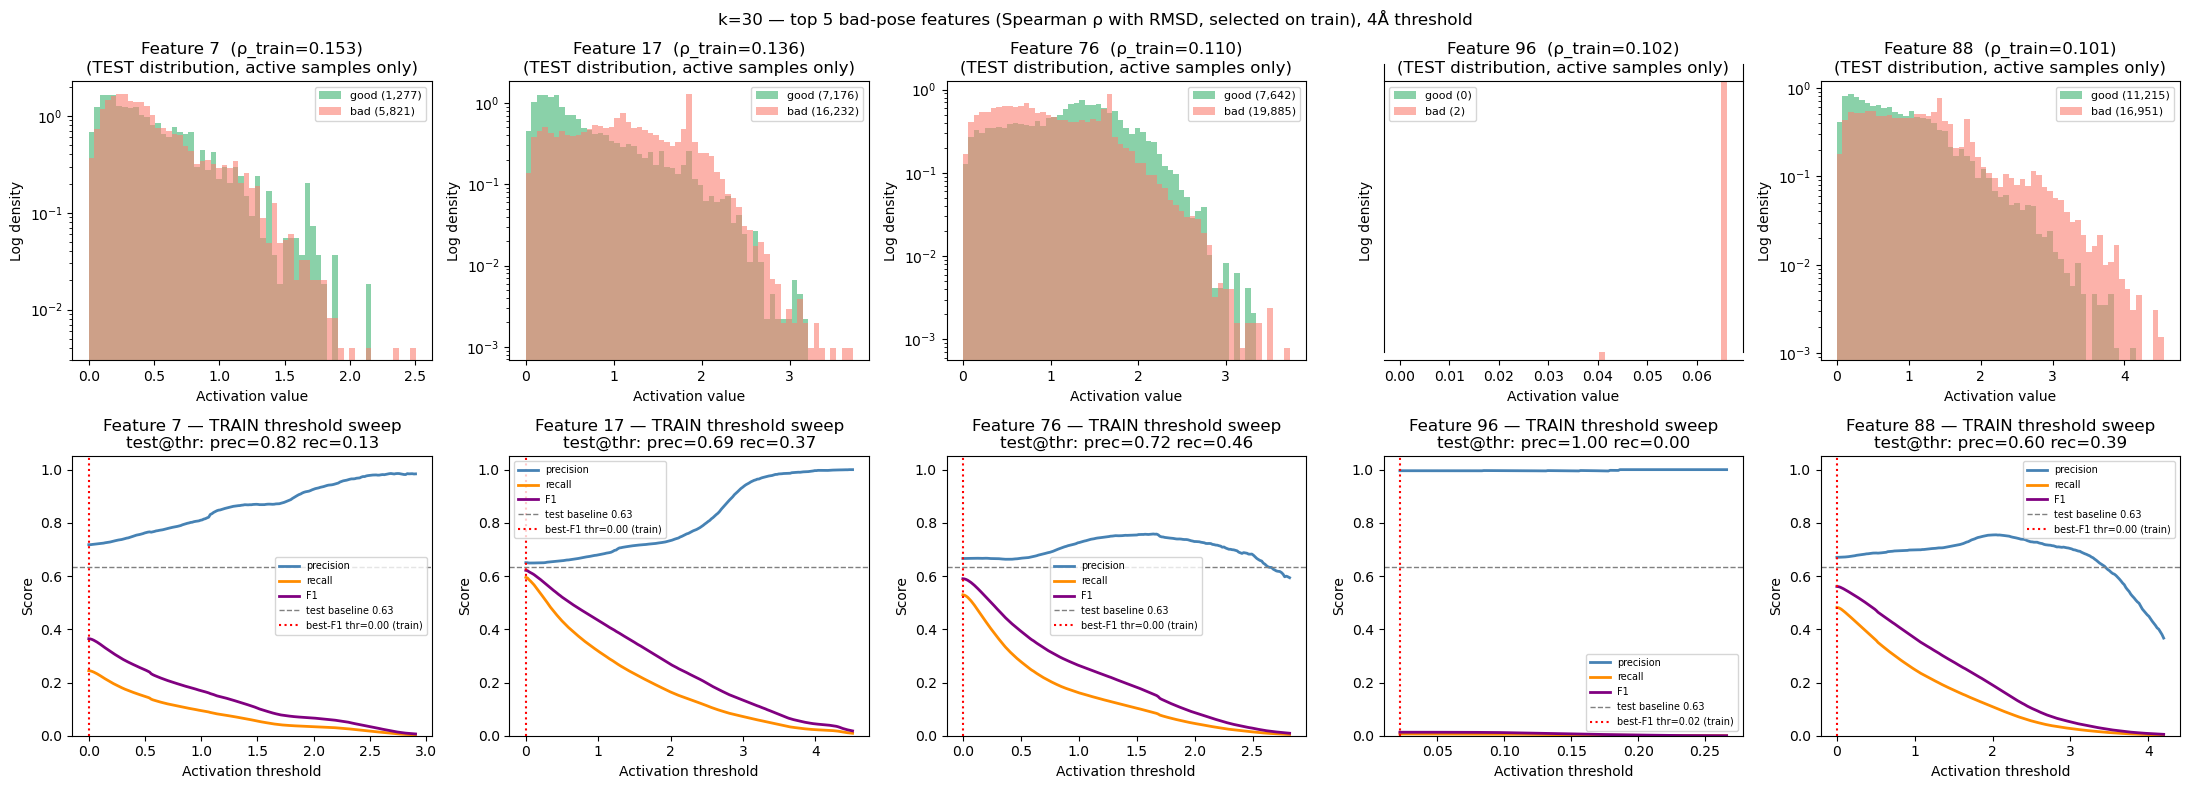

In [10]:
# top_spearman is selected from TRAIN correlations only (train_feature_dfs, section 5).
# Thresholds below are also swept on TRAIN and applied once to TEST — same
# train-select/test-evaluate discipline as section 9's threshold_stats().
top_spearman = {k: train_feature_dfs[k].nlargest(5, "corr_rmsd")["feature"].astype(int).tolist()
                for k in K_VALUES}
print("Top 5 by Spearman (train):", top_spearman)

y_bad_test  = (~good_mask).astype(int)
y_bad_train = (~good_mask_train).astype(int)
y_bad_val   = (~good_mask_val).astype(int)
baseline_bad = y_bad_test.mean()
print(f"Baseline bad-pose rate (test): {baseline_bad:.3f}  ({baseline_bad*100:.1f}%)")

best_thresholds = {}  # {k: {feat: best_thr}}  -- chosen from TRAIN only

for k in K_VALUES:
    acts_train_k = features_train[k]
    acts_test_k  = features_test[k]
    top_feats    = top_spearman[k]
    best_thresholds[k] = {}

    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    fig.suptitle(f"k={k} — top 5 bad-pose features (Spearman ρ with RMSD, selected on train), 4Å threshold",
                 fontsize=12)

    for col, feat in enumerate(top_feats):
        # --- Selection: sweep on TRAIN activations/labels only ---
        a_train      = acts_train_k[:, feat]
        active_train = a_train > 0
        a_act_train  = a_train[active_train]
        y_act_train  = y_bad_train[active_train]

        corr_r = train_feature_dfs[k].loc[train_feature_dfs[k]["feature"]==feat, "corr_rmsd"].values[0]

        thresholds = np.linspace(a_act_train.min(), np.percentile(a_act_train, 99), 200)
        precisions, recalls, f1s = [], [], []
        for thr in thresholds:
            flagged = a_train >= thr
            if flagged.sum() == 0: continue
            prec = y_bad_train[flagged].mean()
            rec  = y_bad_train[flagged].sum() / y_bad_train.sum()
            f1   = 2*prec*rec / (prec+rec+1e-9)
            precisions.append(prec); recalls.append(rec); f1s.append(f1)

        best_idx = int(np.argmax(f1s))
        best_thr = thresholds[best_idx]
        best_thresholds[k][feat] = best_thr

        # --- Evaluation: apply the train-chosen threshold once to TEST ---
        a_test      = acts_test_k[:, feat]
        active_test = a_test > 0
        a_act_test  = a_test[active_test]
        y_act_test  = y_bad_test[active_test]

        test_flagged = a_test >= best_thr
        test_prec = y_bad_test[test_flagged].mean() if test_flagged.sum() > 0 else float('nan')
        test_rec  = y_bad_test[test_flagged].sum() / y_bad_test.sum() if test_flagged.sum() > 0 else float('nan')
        test_f1   = 2*test_prec*test_rec / (test_prec+test_rec+1e-9) if test_flagged.sum() > 0 else float('nan')

        print(f"\nk={k}, Feature {feat} (ρ_train={corr_r:.3f}): "
              f"train active={active_train.sum():,} ({active_train.mean()*100:.1f}%)  "
              f"test active={active_test.sum():,} ({active_test.mean()*100:.1f}%)")
        print(f"  Train-selected thr={best_thr:.3f}  "
              f"(train: prec={precisions[best_idx]:.3f} rec={recalls[best_idx]:.3f} F1={f1s[best_idx]:.3f})")
        print(f"  Applied to test:   prec={test_prec:.3f}  rec={test_rec:.3f}  F1={test_f1:.3f}  "
              f"flagged={test_flagged.sum():,}")

        # Row 0: TEST activation distributions (descriptive only, not used for selection)
        ax = axes[0, col]
        bins = np.linspace(0, a_act_test.max() if len(a_act_test) else 1.0, 60)
        ax.hist(a_act_test[y_act_test==0], bins=bins, density=True, alpha=0.6,
                color="mediumseagreen", label=f"good ({(y_act_test==0).sum():,})")
        ax.hist(a_act_test[y_act_test==1], bins=bins, density=True, alpha=0.6,
                color="salmon",        label=f"bad ({(y_act_test==1).sum():,})")
        ax.set_yscale("log")
        ax.set_xlabel("Activation value")
        ax.set_ylabel("Log density")
        ax.set_title(f"Feature {feat}  (ρ_train={corr_r:.3f})\n(TEST distribution, active samples only)")
        ax.legend(fontsize=8)

        # Row 1: TRAIN threshold sweep (this is what actually picked best_thr)
        ax2 = axes[1, col]
        t = thresholds[:len(f1s)]
        ax2.plot(t, precisions, color="steelblue",  lw=2, label="precision")
        ax2.plot(t, recalls,    color="darkorange", lw=2, label="recall")
        ax2.plot(t, f1s,        color="purple",     lw=2, label="F1")
        ax2.axhline(baseline_bad, color="grey", linestyle="--", lw=1,
                    label=f"test baseline {baseline_bad:.2f}")
        ax2.axvline(best_thr, color="red", linestyle=":", lw=1.5,
                    label=f"best-F1 thr={best_thr:.2f} (train)")
        ax2.set_xlabel("Activation threshold")
        ax2.set_ylabel("Score")
        ax2.set_title(f"Feature {feat} — TRAIN threshold sweep\ntest@thr: prec={test_prec:.2f} rec={test_rec:.2f}")
        ax2.legend(fontsize=7)
        ax2.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"threshold_sweep_k{k}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


In [11]:
from itertools import combinations

ablation_results = {}

for k in K_VALUES:
    acts      = features_test[k]
    top_feats = top_spearman[k]
    flags     = {f: (acts[:, f] >= best_thresholds[k][f]).astype(int) for f in top_feats}

    records = []
    for r in range(1, len(top_feats)+1):
        for combo in combinations(top_feats, r):
            combined = np.zeros(len(y_bad_test), dtype=int)
            for feat in combo: combined |= flags[feat]
            flagged = combined.astype(bool)
            if flagged.sum() == 0: continue
            prec      = y_bad_test[flagged].mean()
            rec       = y_bad_test[flagged].sum() / y_bad_test.sum()
            f1        = 2*prec*rec / (prec+rec+1e-9)
            good_kept = (~flagged)[y_bad_test==0].mean()
            records.append({
                "subset":      "+".join(str(f) for f in combo),
                "n_flagged":   int(flagged.sum()),
                "pct_flagged": flagged.mean()*100,
                "precision":   prec,
                "recall":      rec,
                "f1":          f1,
                "good_kept":   good_kept,
            })

    abl_df = pd.DataFrame(records)
    ablation_results[k] = abl_df
    abl_df.to_csv(os.path.join(OUT_DIR, f"ablation_k{k}.csv"), index=False)

    print(f"\n=== k={k} ablation (4Å threshold) ===")
    print(f"Baseline bad-pose rate: {baseline_bad:.3f}")
    print(f"{'subset':<25} {'n_flag':>7} {'%flag':>6} "
          f"{'prec':>7} {'recall':>7} {'F1':>7} {'good_kept':>10}")
    print("-" * 73)
    for _, row in abl_df.iterrows():
        print(f"{row['subset']:<25} {row['n_flagged']:>7,} "
              f"{row['pct_flagged']:>6.1f}% "
              f"{row['precision']:>7.3f} {row['recall']:>7.3f} "
              f"{row['f1']:>7.3f} {row['good_kept']:>10.3f}")
    print(f"  Saved: ablation_k{k}.csv")



=== k=3 ablation (4Å threshold) ===
Baseline bad-pose rate: 0.634
subset                     n_flag  %flag    prec  recall      F1  good_kept
-------------------------------------------------------------------------
24                             11    0.0%   1.000   0.000   0.001      1.000
66                            923    1.3%   0.898   0.019   0.037      0.996
109                             1    0.0%   1.000   0.000   0.000      1.000
43                          2,870    4.2%   0.172   0.011   0.021      0.905
6+24                           11    0.0%   1.000   0.000   0.001      1.000
6+66                          923    1.3%   0.898   0.019   0.037      0.996
6+109                           1    0.0%   1.000   0.000   0.000      1.000
6+43                        2,870    4.2%   0.172   0.011   0.021      0.905
24+66                         934    1.4%   0.899   0.019   0.038      0.996
24+109                         12    0.0%   1.000   0.000   0.001      1.000
24+43        

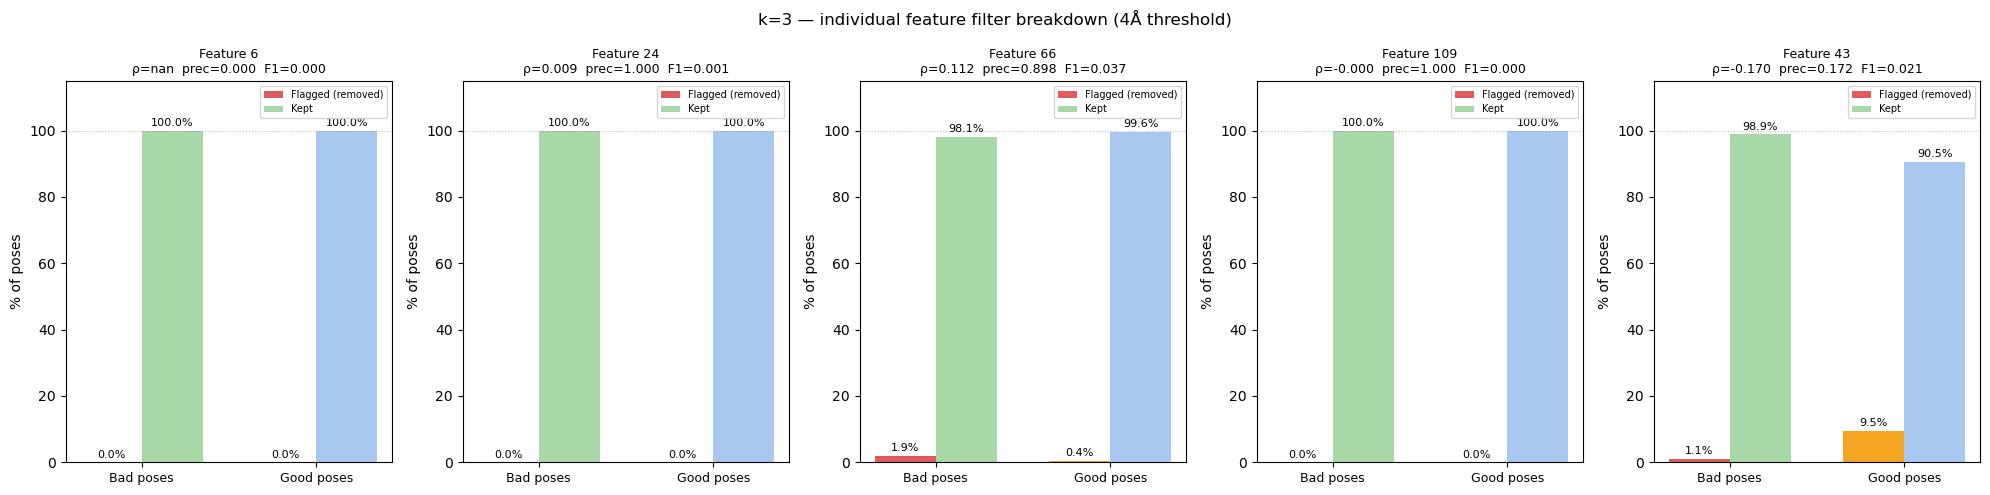

Saved: feature_filter_breakdown_k3.png


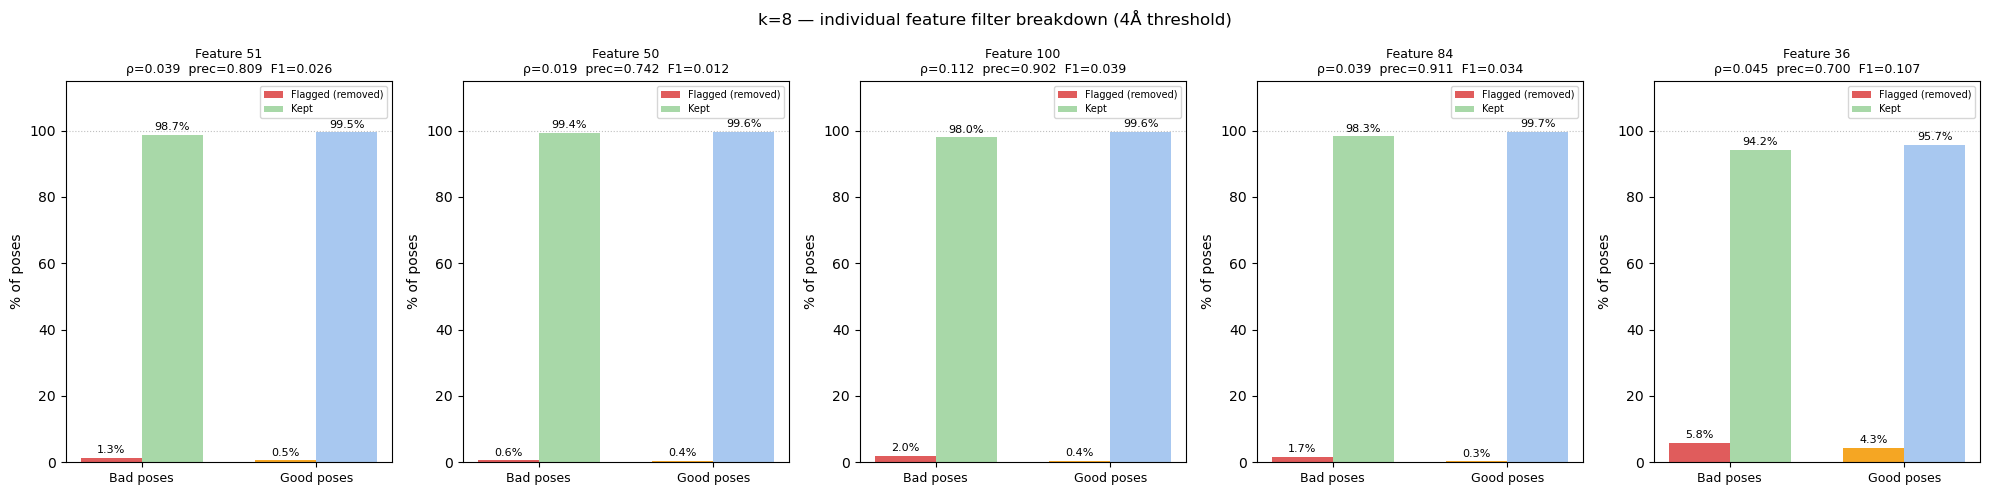

Saved: feature_filter_breakdown_k8.png


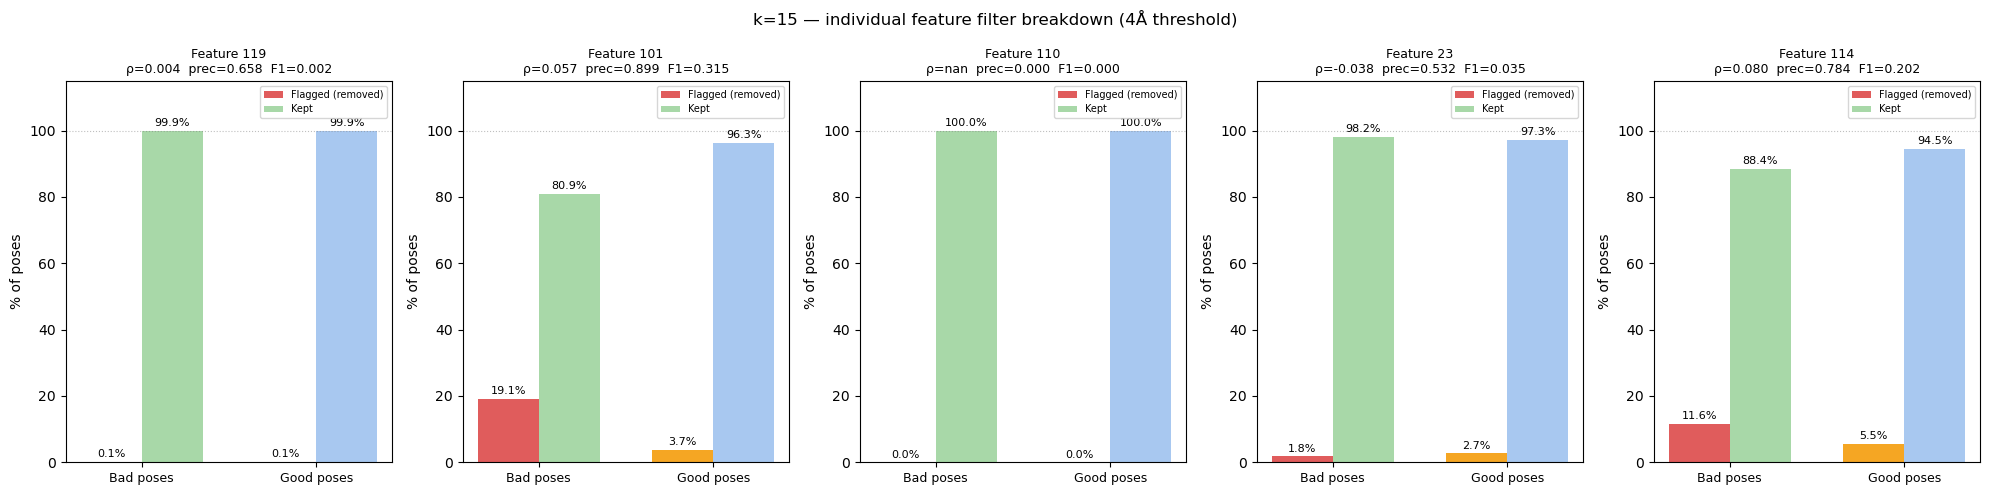

Saved: feature_filter_breakdown_k15.png


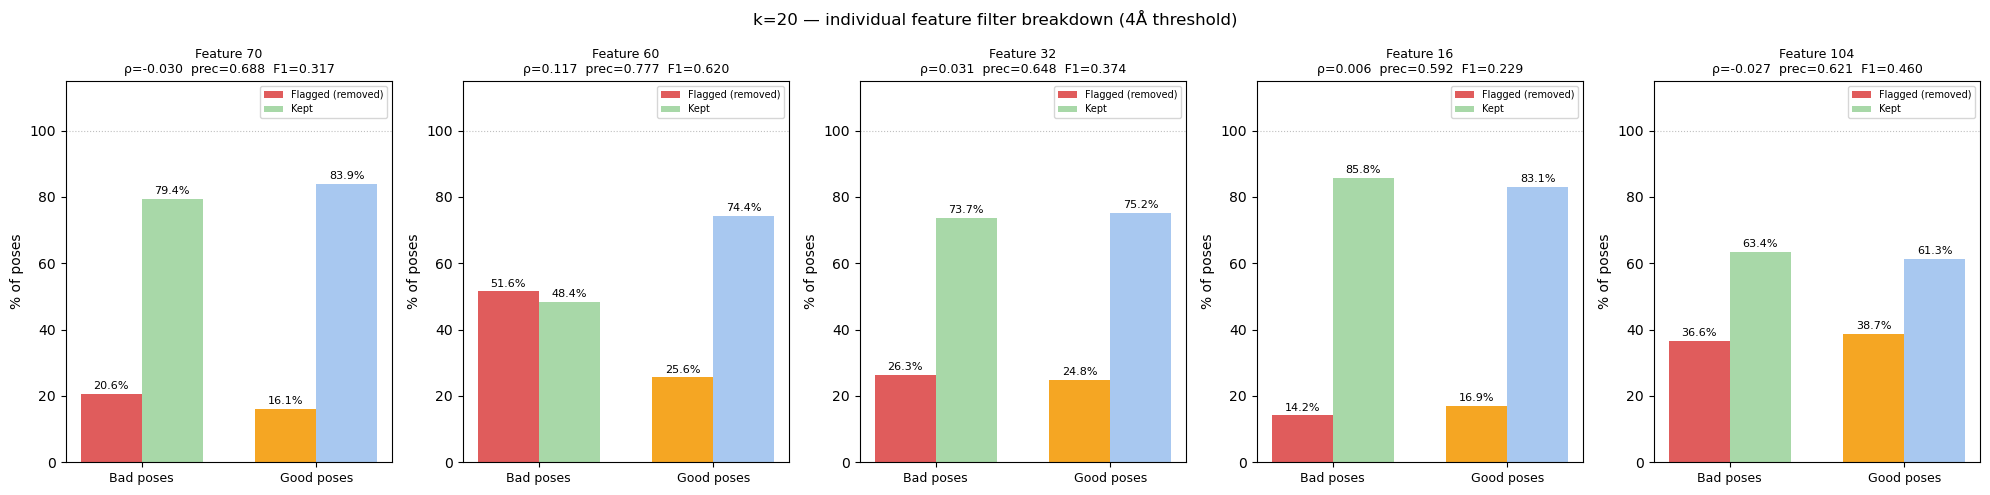

Saved: feature_filter_breakdown_k20.png


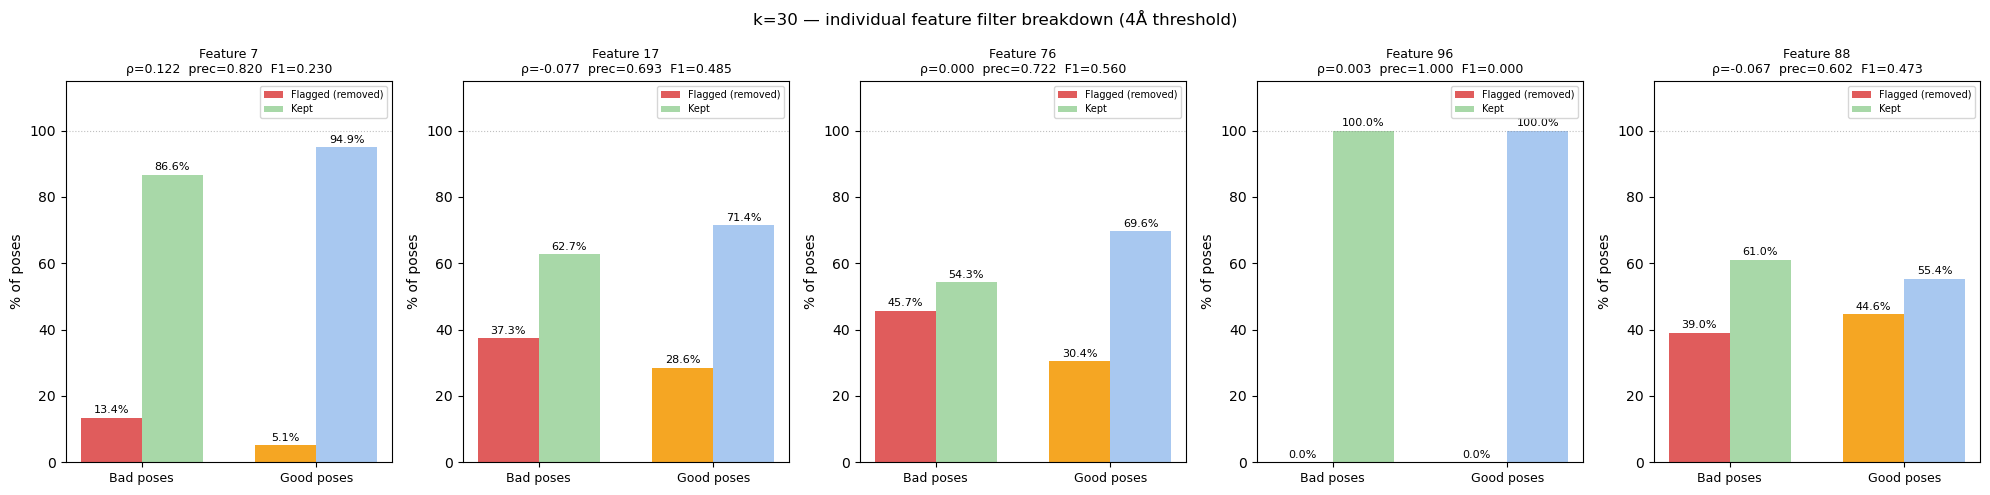

Saved: feature_filter_breakdown_k30.png


In [12]:
# Individual feature filter plots — one figure per k
# For each feature: % bad poses flagged (recall) and % good poses flagged (false alarm)
# plus precision shown as a marker

for k in K_VALUES:
    acts      = features_test[k]
    top_feats = top_spearman[k]
    n         = len(top_feats)

    # Compute per-feature stats at best-F1 threshold
    rows = []
    for feat in top_feats:
        thr     = best_thresholds[k][feat]
        flagged = acts[:, feat] >= thr
        n_bad   = y_bad_test.sum()
        n_good  = (~good_mask).size - n_bad
        bad_flagged  = (flagged &  y_bad_test.astype(bool)).sum()
        good_flagged = (flagged & ~y_bad_test.astype(bool)).sum()
        bad_kept     = (~flagged &  y_bad_test.astype(bool)).sum()
        good_kept_n  = (~flagged & ~y_bad_test.astype(bool)).sum()
        corr_r = all_feature_dfs[k].loc[
            all_feature_dfs[k]["feature"]==feat, "corr_rmsd"].values[0]
        rows.append({
            "feat":          feat,
            "corr_r":        corr_r,
            "pct_bad_flagged":  bad_flagged  / n_bad  * 100,
            "pct_bad_kept":     bad_kept     / n_bad  * 100,
            "pct_good_flagged": good_flagged / (len(y_bad_test) - n_bad) * 100,
            "pct_good_kept":    good_kept_n  / (len(y_bad_test) - n_bad) * 100,
            "precision": y_bad_test[flagged].mean() if flagged.sum() > 0 else 0,
            "f1": ablation_results[k].loc[
                ablation_results[k]["subset"]==str(feat), "f1"].values[0]
                  if str(feat) in ablation_results[k]["subset"].values else 0,
        })

    fig, axes = plt.subplots(1, n, figsize=(4*n, 5), sharey=False)
    fig.suptitle(f"k={k} — individual feature filter breakdown (4Å threshold)",
                 fontsize=12)

    for ax, row in zip(axes, rows):
        feat = row["feat"]
        categories = ["Bad poses", "Good poses"]
        flagged_pct = [row["pct_bad_flagged"], row["pct_good_flagged"]]
        kept_pct    = [row["pct_bad_kept"],    row["pct_good_kept"]]

        x = np.arange(2)
        w = 0.35
        bars_flag = ax.bar(x - w/2, flagged_pct, w,
                           color=["#e05c5c", "#f5a623"], label="Flagged (removed)")
        bars_kept = ax.bar(x + w/2, kept_pct, w,
                           color=["#a8d8a8", "#a8c8f0"], label="Kept")

        # Annotate bars
        for bar in list(bars_flag) + list(bars_kept):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                    f"{h:.1f}%", ha="center", va="bottom", fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(categories, fontsize=9)
        ax.set_ylim(0, 115)
        ax.set_ylabel("% of poses")
        ax.set_title(
            f"Feature {feat}\n"
            f"ρ={row['corr_r']:.3f}  prec={row['precision']:.3f}  F1={row['f1']:.3f}",
            fontsize=9
        )
        ax.legend(fontsize=7, loc="upper right")
        ax.axhline(100, color="grey", linestyle=":", lw=0.8, alpha=0.5)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"feature_filter_breakdown_k{k}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: feature_filter_breakdown_k{k}.png")


### 8. Summary

In [13]:
output_files = [
    "metadata.csv",
    "features_for_paper.npz",
    "top_features_k3.csv",
    "top_features_k8.csv",
    "top_features_k15.csv",
    "roc_auc_comparison.png",
    "threshold_sweep_k3.png",
    "threshold_sweep_k8.png",
    "threshold_sweep_k15.png",
    "ablation_k3.csv",
    "ablation_k8.csv",
    "ablation_k15.csv",
    "ablation_plot_k3.png",
    "ablation_plot_k8.png",
    "ablation_plot_k15.png",
]
print("Output files:")
for fname in output_files:
    fpath = os.path.join(OUT_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f"  {fname:<38s}  {size:8.1f} KB")
    else:
        print(f"  {fname:<38s}  (not yet generated)")

print(f"\nThreshold: {RMSD_THRESHOLD}Å  |  Test set: {len(test_idx):,} samples")
print("\nROC-AUC summary:")
for name, auc in roc_results.items():
    print(f"  {name:<30}  auPR={aupr_results[name]:.4f}  AUC={auc:.4f}")


Output files:
  metadata.csv                             31404.1 KB
  features_for_paper.npz                    9339.9 KB
  top_features_k3.csv                          2.3 KB
  top_features_k8.csv                          2.4 KB
  top_features_k15.csv                         2.0 KB
  roc_auc_comparison.png                     173.8 KB
  threshold_sweep_k3.png                     201.8 KB
  threshold_sweep_k8.png                     211.4 KB
  threshold_sweep_k15.png                    222.3 KB
  ablation_k3.csv                              3.1 KB
  ablation_k8.csv                              3.4 KB
  ablation_k15.csv                             3.3 KB
  ablation_plot_k3.png                    (not yet generated)
  ablation_plot_k8.png                    (not yet generated)
  ablation_plot_k15.png                   (not yet generated)

Threshold: 4.0Å  |  Test set: 68,614 samples

ROC-AUC summary:
  Raw latents (30-dim)            auPR=0.7697  AUC=0.7146
  SAE k=3  (120-dim)          

In [14]:
# All poses where top Spearman features activate — train + test, all k values
# (metadata_train already defined in section 2)

records = []
for k in K_VALUES:
    top_feats  = top_spearman[k]
    thresholds = best_thresholds[k]

    for split_name, acts, meta_split in [
        ('train', features_train[k], metadata_train),
        ('test',  features_test[k],  metadata_test),
    ]:
        for feat in top_feats:
            thr      = thresholds[feat]
            act_vals = acts[:, feat]
            firing   = act_vals > 0
            for local_idx in np.where(firing)[0]:
                row = meta_split.iloc[local_idx]
                records.append({
                    'k':            k,
                    'split':        split_name,
                    'feature':      feat,
                    'case_id':      row['case_id'],
                    'sample_idx':   row['sample_idx'],
                    'global_idx':   row['global_idx'],
                    'rmsd':         row['rmsd'],
                    'energy':       row['energy'],
                    'activation':   float(act_vals[local_idx]),
                    'above_thresh': bool(act_vals[local_idx] >= thr),
                    'is_bad_pose':  bool(~row['good_pose']),
                })

feature_activations_df = pd.DataFrame(records)
out_path = os.path.join(OUT_DIR, 'feature_activations_top5.csv')
feature_activations_df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Total rows: {len(feature_activations_df):,}")
print()
summary = (feature_activations_df
           .groupby(['k', 'feature', 'split', 'above_thresh'])
           .size()
           .rename('n_poses'))
print(summary.to_string())


Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/feature_activations_top5.csv
Total rows: 1,494,047

k   feature  split  above_thresh
3   6        train  True              5777
    24       test   True                11
             train  True              5701
    43       test   True              2870
             train  True              3644
    66       test   False                2
                    True               923
             train  True              8019
    109      test   True                 1
             train  True              3105
8   36       test   True              3605
             train  True             21229
    50       test   True               360
             train  True             10196
    51       test   True               711
             train  True             12612
    84       test   True               827
             train  True             12570
    100      test   True               958
             train  True              8

### 9. Random Direction Control

The `threshold_stats` helper defined below (train-select / test-evaluate) is reused throughout Sections 11-14. The random-direction/raw-axis *comparison* itself has been rebuilt to use the same pooled train+val selection discipline as the Section 12 SAE filters -- see "9. Random Direction Control (rebuilt)" immediately after Section 12, which benchmarks against the current k=3/8/15 headline filters instead of the stale train-only, old-feature-index comparison this cell used to compute.


In [15]:
N_RANDOM = 500
np.random.seed(42)

def threshold_stats(scores_train, scores_test, y_bad_train, y_bad_test, n_thresholds=200):
    """Sweep thresholds on train (maximise F1), apply best to test. Returns None if no valid threshold."""
    hi = scores_train.max()
    if hi <= 0:
        return None
    # For sparse features, sweep up to max; for dense, cap outliers at 99th pct
    hi = min(hi, np.percentile(scores_train[scores_train > 0], 99)) if (scores_train > 0).sum() > 0 else hi
    thresholds = np.linspace(0, hi, n_thresholds + 1)[1:]  # skip threshold=0
    best_f1, best_thr = -1.0, None
    for thr in thresholds:
        flagged = scores_train >= thr
        if flagged.sum() < 10:
            continue
        prec = y_bad_train[flagged].mean()
        rec  = y_bad_train[flagged].sum() / y_bad_train.sum()
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    if best_thr is None:
        return None
    flagged_test = scores_test >= best_thr
    if flagged_test.sum() == 0:
        return None
    prec = y_bad_test[flagged_test].mean()
    rec  = y_bad_test[flagged_test].sum() / y_bad_test.sum()
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return {'precision': prec, 'recall': rec, 'f1': f1,
            'n_flagged': int(flagged_test.sum()),
            'pct_flagged': flagged_test.mean() * 100}



### 11. Rebuilt combined filter (new models — features re-identified from scratch)

SAE feature indices are not stable across separate training runs (different seed/data ->
unrelated learned basis), so the GenBio-submission feature numbers (e.g. k=3 feat 70/107)
have no special meaning in these `07_30_26` models — confirmed above, where those exact
indices now score precision 0.401/0.486 with near-zero recall, worse than the random-
direction/raw-axis baselines.

This section redoes the search properly for the new models: for every feature in k=3, 8,
15, sweep the best-F1 threshold on TRAIN and apply once to TEST (identical discipline to
`threshold_stats` above, just extended across k and ranked by F1 instead of raw precision
so we don't pick degenerate "precision=1.0 on 3 poses" features). Top-F1 features per k are
then combined into a union filter, evaluated on TEST, to get a fresh version of the
21%-flagged / 90%-good-retained-style headline stat.

In [16]:
# SELECTION set = train+val pooled (more data to search over than val alone).
# Test remains completely untouched by fitting/ranking/combo-search below; it is
# evaluated exactly once, at the very end, on the combo already fixed by pooled selection.
features_pool = {k: np.concatenate([features_train[k], features_val[k]], axis=0) for k in K_VALUES}
y_bad_pool    = np.concatenate([y_bad_train, y_bad_val])
print(f'Pooled train+val selection set: {len(y_bad_pool):,} poses '
      f'({(1 - y_bad_pool.mean())*100:.1f}% good)')

rebuilt_sae_dfs = {}
for k in K_VALUES:
    recs = []
    for feat in range(120):
        r = threshold_stats(features_pool[k][:, feat], features_pool[k][:, feat], y_bad_pool, y_bad_pool)
        if r:
            recs.append({'feature': feat, **r})
    rebuilt_sae_dfs[k] = pd.DataFrame(recs)
    df = rebuilt_sae_dfs[k]
    print(f"k={k}: {len(df)} features with a valid threshold  "
          f"(max F1={df['f1'].max():.3f}, max precision={df['precision'].max():.3f})  [train+val pooled]")

print()
for k in K_VALUES:
    print(f"\n=== k={k} -- top 8 by F1 (pooled train+val selection) ===")
    print(rebuilt_sae_dfs[k].nlargest(8, 'f1')[['feature', 'precision', 'recall', 'pct_flagged', 'f1']]
          .to_string(index=False, float_format='{:.3f}'.format))

# Top 5 per k by F1 on the pooled selection set -> candidate filter features. Test is not touched.
top_f1_feats = {k: rebuilt_sae_dfs[k].nlargest(5, 'f1')['feature'].astype(int).tolist() for k in K_VALUES}
print(f"\nTop-5-by-F1 candidate features per k (selected on pooled train+val): {top_f1_feats}")

# Re-derive each feature's pooled-selected threshold (threshold_stats() doesn't return it,
# so recompute directly here, same sweep, keeping the threshold this time).
def best_train_threshold(scores_train, y_bad_train, n_thresholds=200):
    hi = scores_train.max()
    if hi <= 0:
        return None
    hi = min(hi, np.percentile(scores_train[scores_train > 0], 99)) if (scores_train > 0).sum() > 0 else hi
    thresholds = np.linspace(0, hi, n_thresholds + 1)[1:]
    best_f1, best_thr = -1.0, None
    for thr in thresholds:
        flagged = scores_train >= thr
        if flagged.sum() < 10:
            continue
        prec = y_bad_train[flagged].mean()
        rec  = y_bad_train[flagged].sum() / y_bad_train.sum()
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr

rebuilt_thresholds = {
    k: {f: best_train_threshold(features_pool[k][:, f], y_bad_pool) for f in top_f1_feats[k]}
    for k in K_VALUES
}

def eval_union(acts, y_bad, feats, thresholds):
    """Evaluate every non-empty union (OR) of `feats`, flagged via `thresholds`, against (acts, y_bad)."""
    flags = {f: (acts[:, f] >= thresholds[f]).astype(int) for f in feats}
    records = []
    for r in range(1, len(feats) + 1):
        for combo in combinations(feats, r):
            combined = np.zeros(len(y_bad), dtype=int)
            for feat in combo: combined |= flags[feat]
            flagged = combined.astype(bool)
            if flagged.sum() == 0: continue
            prec      = y_bad[flagged].mean()
            rec       = y_bad[flagged].sum() / y_bad.sum()
            f1        = 2 * prec * rec / (prec + rec + 1e-9)
            good_kept = (~flagged)[y_bad == 0].mean()
            records.append({
                "subset": "+".join(str(f) for f in combo), "n_flagged": int(flagged.sum()),
                "pct_flagged": flagged.mean() * 100, "precision": prec, "recall": rec,
                "f1": f1, "good_kept": good_kept,
            })
    return pd.DataFrame(records)

def eval_combo(acts, y_bad, combo, thresholds):
    """Evaluate the union of exactly this one feature combo (no sub-combo enumeration)."""
    flagged = np.zeros(len(y_bad), dtype=bool)
    for feat in combo:
        flagged |= (acts[:, feat] >= thresholds[feat])
    n = int(flagged.sum())
    prec      = y_bad[flagged].mean() if n > 0 else float('nan')
    rec       = y_bad[flagged].sum() / y_bad.sum() if n > 0 else float('nan')
    f1        = 2 * prec * rec / (prec + rec + 1e-9) if n > 0 else float('nan')
    good_kept = (~flagged)[y_bad == 0].mean()
    return {'subset': "+".join(str(f) for f in combo), 'n_flagged': n,
            'pct_flagged': flagged.mean() * 100, 'precision': prec, 'recall': rec,
            'f1': f1, 'good_kept': good_kept}

# Combo SELECTION happens on the pooled train+val set only -- test is not searched over,
# only evaluated once at the very end with the combo already fixed.
rebuilt_ablation_val  = {}
rebuilt_winning_combo = {}
rebuilt_test_result   = {}
for k in K_VALUES:
    feats  = top_f1_feats[k]
    val_df = eval_union(features_pool[k], y_bad_pool, feats, rebuilt_thresholds[k])
    rebuilt_ablation_val[k] = val_df

    print(f"\n=== k={k} rebuilt combined filter (pooled train+val selection) ===")
    print(f"{'subset':<25} {'n_flag':>7} {'%flag':>6} {'prec':>7} {'recall':>7} {'F1':>7} {'good_kept':>10}")
    print("-" * 73)
    for _, row in val_df.iterrows():
        print(f"{row['subset']:<25} {row['n_flagged']:>7,} {row['pct_flagged']:>6.1f}% "
              f"{row['precision']:>7.3f} {row['recall']:>7.3f} {row['f1']:>7.3f} {row['good_kept']:>10.3f}")

    best_row_val  = val_df.loc[val_df['f1'].idxmax()]
    winning_combo = [int(f) for f in best_row_val['subset'].split('+')]
    rebuilt_winning_combo[k] = winning_combo
    print(f"\n  Best-F1 combo for k={k} (chosen on pooled train+val): {best_row_val['subset']}  "
          f"({best_row_val['pct_flagged']:.1f}% of pooled poses flagged, "
          f"precision={best_row_val['precision']:.3f}, recall={best_row_val['recall']:.3f}, "
          f"good_kept={best_row_val['good_kept']*100:.1f}%)")

    # One-shot TEST evaluation of the pooled-selected combo -- test never influenced the choice.
    test_row = eval_combo(features_test[k], y_bad_test, winning_combo, rebuilt_thresholds[k])
    rebuilt_test_result[k] = test_row
    print(f"  --> Applied once to TEST: {test_row['pct_flagged']:.1f}% flagged, "
          f"precision={test_row['precision']:.3f}, recall={test_row['recall']:.3f}, "
          f"good_kept={test_row['good_kept']*100:.1f}%")


Pooled train+val selection set: 366,455 poses (35.8% good)


k=3: 120 features with a valid threshold  (max F1=0.163, max precision=1.000)  [train+val pooled]


k=8: 120 features with a valid threshold  (max F1=0.527, max precision=0.974)  [train+val pooled]


k=15: 120 features with a valid threshold  (max F1=0.668, max precision=1.000)  [train+val pooled]


k=20: 119 features with a valid threshold  (max F1=0.590, max precision=1.000)  [train+val pooled]


k=30: 90 features with a valid threshold  (max F1=0.739, max precision=1.000)  [train+val pooled]


=== k=3 -- top 8 by F1 (pooled train+val selection) ===
 feature  precision  recall  pct_flagged    f1
      77      0.664   0.093        8.973 0.163
      71      0.582   0.091        9.988 0.157
      39      0.798   0.069        5.578 0.128
      51      0.732   0.069        6.092 0.127
      95      0.593   0.066        7.092 0.118
      15      0.639   0.064        6.437 0.116
      91      0.730   0.062        5.489 0.115
     106      0.776   0.059        4.893 0.110

=== k=8 -- top 8 by F1 (pooled train+val selection) ===
 feature  precision  recall  pct_flagged    f1
      60      0.662   0.438       42.469 0.527
      69      0.651   0.336       33.111 0.443
     119      0.657   0.290       28.301 0.402
      62      0.674   0.273       26.059 0.389
      40      0.622   0.278       28.726 0.384
      83      0.709   0.253       22.945 0.373
      26      0.628   0.212       2


=== k=3 rebuilt combined filter (pooled train+val selection) ===
subset                     n_flag  %flag    prec  recall      F1  good_kept
-------------------------------------------------------------------------
77                         32,881    9.0%   0.664   0.093   0.163      0.916
71                         36,601   10.0%   0.582   0.091   0.157      0.883
39                         20,441    5.6%   0.798   0.069   0.128      0.969
51                         22,326    6.1%   0.732   0.069   0.127      0.954
95                         25,988    7.1%   0.593   0.066   0.118      0.919
77+71                      66,307   18.1%   0.616   0.173   0.271      0.806
77+39                      50,984   13.9%   0.714   0.155   0.254      0.889
77+51                      51,120   13.9%   0.680   0.148   0.243      0.875
77+95                      56,166   15.3%   0.619   0.148   0.238      0.837
71+39                      55,967   15.3%   0.656   0.156   0.252      0.853
71+51         


=== k=15 rebuilt combined filter (pooled train+val selection) ===
subset                     n_flag  %flag    prec  recall      F1  good_kept
-------------------------------------------------------------------------
42                        266,616   72.8%   0.629   0.713   0.668      0.246
97                        197,410   53.9%   0.640   0.537   0.584      0.459
100                       147,788   40.3%   0.676   0.425   0.522      0.635
59                        147,009   40.1%   0.678   0.423   0.521      0.638
35                        137,253   37.5%   0.663   0.387   0.489      0.648
42+97                     324,322   88.5%   0.630   0.868   0.730      0.084
42+100                    309,176   84.4%   0.644   0.845   0.731      0.159
42+59                     306,081   83.5%   0.639   0.831   0.722      0.157
42+35                     299,361   81.7%   0.636   0.809   0.712      0.169
97+100                    263,279   71.8%   0.657   0.735   0.693      0.311
97+59        


=== k=30 rebuilt combined filter (pooled train+val selection) ===
subset                     n_flag  %flag    prec  recall      F1  good_kept
-------------------------------------------------------------------------
35                        320,249   87.4%   0.641   0.873   0.739      0.124
89                        303,550   82.8%   0.647   0.834   0.729      0.183
67                        310,407   84.7%   0.636   0.839   0.724      0.139
82                        252,299   68.8%   0.667   0.715   0.690      0.359
101                       254,661   69.5%   0.662   0.717   0.689      0.344
35+89                     361,140   98.5%   0.644   0.988   0.780      0.019
35+67                     362,385   98.9%   0.642   0.989   0.778      0.011
35+82                     356,124   97.2%   0.646   0.977   0.777      0.037
35+101                    358,164   97.7%   0.644   0.980   0.777      0.028
89+67                     344,714   94.1%   0.637   0.933   0.757      0.045
89+82        

### 12. Good-pose-retention-targeted filter (k=8, k=15)

Section 11's top-5-by-F1 selection favors high recall / low precision for k=8 and k=15 —
their best combos flag 90%+ of *all* poses, which isn't a usable pre-refinement filter.
k=3's useful operating point (39+71: 19.1% flagged, 90.1% good retained) came from F1
happening to prefer a conservative pair for that k; it won't for every k.

Here we target the operating point directly: from each k's full 120-feature TRAIN-selected
sweep (`rebuilt_sae_dfs`, section 11), take the top candidates by **precision** (excluding
near-zero-recall artifacts, i.e. require recall > 0.02 so we're not cherry-picking a feature
that fires on 3 poses), then search unions of those candidates on TEST for the combo that
maximizes recall subject to keeping good_kept >= 0.85 — the same "conservative filter"
regime the paper's k=3 result sits in.

In [17]:
GOOD_KEPT_MIN = 0.80
N_CANDIDATES  = 16

targeted_thresholds    = {}
targeted_ablation_val  = {}
targeted_winning_combo = {}
targeted_test_result   = {}

for k in [3, 8, 15]:
    df = rebuilt_sae_dfs[k]   # pooled train+val evaluated (section 11)
    candidates = (df[df['recall'] > 0.02]
                  .nlargest(N_CANDIDATES, 'precision')['feature']
                  .astype(int).tolist())
    print(f"\nk={k} -- top {len(candidates)} candidates by precision (pooled train+val, recall>0.02): {candidates}")
    print(df[df['feature'].isin(candidates)][['feature', 'precision', 'recall', 'pct_flagged', 'f1']]
          .to_string(index=False, float_format='{:.3f}'.format))

    thresholds = {f: best_train_threshold(features_pool[k][:, f], y_bad_pool) for f in candidates}
    targeted_thresholds[k] = thresholds

    val_abl_df = eval_union(features_pool[k], y_bad_pool, candidates, thresholds)
    targeted_ablation_val[k] = val_abl_df

    feasible = val_abl_df[val_abl_df['good_kept'] >= GOOD_KEPT_MIN]
    print(f"\n  {len(feasible)}/{len(val_abl_df)} combos keep good_kept >= {GOOD_KEPT_MIN:.0%} (pooled train+val)")
    if len(feasible) > 0:
        best = feasible.loc[feasible['recall'].idxmax()]
        print(f"  Best (max recall @ good_kept>={GOOD_KEPT_MIN:.0%}) for k={k} (chosen on pooled train+val): {best['subset']}  "
              f"({best['pct_flagged']:.1f}% flagged, precision={best['precision']:.3f}, "
              f"recall={best['recall']:.3f}, good_kept={best['good_kept']*100:.1f}%)")
    else:
        best = val_abl_df.loc[val_abl_df['good_kept'].idxmax()]
        print(f"  No combo reaches good_kept>={GOOD_KEPT_MIN:.0%} for k={k} on pooled train+val. "
              f"Closest: {best['subset']}  ({best['pct_flagged']:.1f}% flagged, "
              f"precision={best['precision']:.3f}, recall={best['recall']:.3f}, "
              f"good_kept={best['good_kept']*100:.1f}%)")

    winning_combo = [int(f) for f in best['subset'].split('+')]
    targeted_winning_combo[k] = winning_combo

    # One-shot TEST evaluation of the pooled-selected combo -- test never influenced the choice.
    test_row = eval_combo(features_test[k], y_bad_test, winning_combo, thresholds)
    targeted_test_result[k] = test_row
    print(f"  --> Applied once to TEST: {test_row['pct_flagged']:.1f}% flagged, "
          f"precision={test_row['precision']:.3f}, recall={test_row['recall']:.3f}, "
          f"good_kept={test_row['good_kept']*100:.1f}%")



k=3 -- top 16 candidates by precision (pooled train+val, recall>0.02): [6, 24, 102, 66, 32, 7, 59, 113, 57, 104, 94, 63, 39, 110, 61, 31]
 feature  precision  recall  pct_flagged    f1
       6      1.000   0.025        1.577 0.048
       7      0.914   0.032        2.256 0.062
      24      0.991   0.024        1.570 0.047
      31      0.794   0.028        2.244 0.054
      32      0.915   0.024        1.674 0.046
      39      0.798   0.069        5.578 0.128
      57      0.850   0.032        2.416 0.062
      59      0.897   0.025        1.805 0.049
      61      0.795   0.053        4.258 0.099
      63      0.812   0.022        1.758 0.043
      66      0.925   0.032        2.221 0.062
      94      0.838   0.022        1.667 0.042
     102      0.941   0.023        1.545 0.044
     104      0.844   0.035        2.650 0.067
     110      0.798   0.024        1.918 0.046
     113      0.858   0.047        3.523 0.089



  65535/65535 combos keep good_kept >= 80% (pooled train+val)
  Best (max recall @ good_kept>=80%) for k=3 (chosen on pooled train+val): 6+24+102+66+32+7+59+113+57+104+94+63+39+110+61+31  (32.6% flagged, precision=0.838, recall=0.426, good_kept=85.2%)
  --> Applied once to TEST: 27.3% flagged, precision=0.698, recall=0.301, good_kept=77.5%

k=8 -- top 16 candidates by precision (pooled train+val, recall>0.02): [51, 10, 28, 100, 50, 118, 71, 43, 85, 102, 84, 91, 98, 53, 2, 12]
 feature  precision  recall  pct_flagged    f1
       2      0.817   0.057        4.509 0.107
      10      0.931   0.037        2.578 0.072
      12      0.789   0.040        3.232 0.076
      28      0.921   0.021        1.460 0.041
      43      0.859   0.021        1.578 0.041
      50      0.890   0.040        2.884 0.076
      51      0.974   0.052        3.447 0.099
      53      0.819   0.037        2.914 0.071
      71      0.862   0.036        2.696 0.069
      84      0.825   0.049        3.848 0.093
 


  65535/65535 combos keep good_kept >= 80% (pooled train+val)
  Best (max recall @ good_kept>=80%) for k=8 (chosen on pooled train+val): 51+10+28+100+50+118+71+43+85+102+84+91+98+53+2+12  (34.1% flagged, precision=0.828, recall=0.440, good_kept=83.6%)
  --> Applied once to TEST: 16.5% flagged, precision=0.803, recall=0.210, good_kept=91.1%

k=15 -- top 16 candidates by precision (pooled train+val, recall>0.02): [119, 81, 101, 23, 5, 30, 16, 99, 82, 94, 106, 59, 40, 100, 114, 107]
 feature  precision  recall  pct_flagged    f1
       5      0.733   0.161       14.069 0.263
      16      0.691   0.296       27.546 0.415
      23      0.733   0.115       10.086 0.199
      30      0.702   0.293       26.778 0.413
      40      0.677   0.196       18.635 0.304
      59      0.678   0.423       40.117 0.521
      81      0.770   0.041        3.460 0.079
      82      0.686   0.228       21.296 0.342
      94      0.684   0.180       16.905 0.285
      99      0.688   0.279       26.060 0.3


  39/65535 combos keep good_kept >= 80% (pooled train+val)
  Best (max recall @ good_kept>=80%) for k=15 (chosen on pooled train+val): 119+81+23+5  (26.9% flagged, precision=0.745, recall=0.312, good_kept=80.8%)
  --> Applied once to TEST: 12.3% flagged, precision=0.879, recall=0.171, good_kept=95.9%


### 9. Random Direction Control (rebuilt — pooled train+val selection, benchmarked against the Section 12 SAE filters)

The original version of this section (trimmed above to just the `threshold_stats` utility) swept a single threshold per direction on the **train split only** and compared against the GenBio-submission SAE feature indices (70/107), which Section 11 already showed are meaningless for the `07_30_26` models. It also gave the SAE side a smaller selection budget than what actually produces the current headline filters (Section 12 uses pooled train+val, top-`N_CANDIDATES` candidates, and a combo search — not a single best direction), so it wasn't an apples-to-apples comparison even before the feature indices went stale.

This section redoes it properly: for two families of raw-latent linear projections — 500 random unit directions in 30D, and all 60 signed raw latent axes — we apply the *identical* selection procedure used for the SAE combo filters above (rank candidates by precision on the pooled train+val set, requiring recall > 0.02 to exclude degenerate near-zero-recall picks, take the top `N_CANDIDATES`, then search unions of those candidates — still on pooled train+val — for the one maximizing recall subject to `good_kept >= GOOD_KEPT_MIN`). The winning combo per family is applied exactly once to the held-out test split and compared directly against `targeted_test_result` from Section 12.


In [18]:
# Raw latents pooled the same way as features_pool in Section 11 -- train+val concatenated.
X_raw_pool = np.concatenate([X_raw_train, X_raw_val], axis=0)
print(f'Raw latent pooled selection set: {X_raw_pool.shape[0]:,} poses')

def build_direction_candidates(directions, dir_labels):
    """Project each direction onto the pooled train+val set and the test set, then rank
    via threshold_stats(pool, pool, ...) exactly as rebuilt_sae_dfs did for SAE features in
    Section 11 -- self-consistent pooled precision/recall/F1, used only for ranking (the
    actual filter threshold is recomputed with best_train_threshold below)."""
    scores_pool = {lbl: X_raw_pool @ d for lbl, d in zip(dir_labels, directions)}
    scores_test = {lbl: X_raw_test @ d for lbl, d in zip(dir_labels, directions)}
    recs = []
    for lbl in dir_labels:
        r = threshold_stats(scores_pool[lbl], scores_pool[lbl], y_bad_pool, y_bad_pool)
        if r:
            recs.append({'direction': lbl, **r})
    return pd.DataFrame(recs), scores_pool, scores_test

random_dirs  = np.random.RandomState(42).randn(N_RANDOM, 30)
random_dirs /= np.linalg.norm(random_dirs, axis=1, keepdims=True)
random_labels = [f'rand_{i}' for i in range(N_RANDOM)]

axis_dirs, axis_labels = [], []
for dim in range(30):
    for sign in [1, -1]:
        d = np.zeros(30); d[dim] = float(sign)
        axis_dirs.append(d)
        axis_labels.append(f'axis_{dim}_{"+" if sign > 0 else "-"}')

direction_families = {
    'Random directions': (random_dirs, random_labels),
    'Raw latent axes':   (axis_dirs,   axis_labels),
}

rebuilt_direction_dfs = {}
direction_scores_pool = {}
direction_scores_test = {}
for fam_name, (dirs, labels) in direction_families.items():
    df, s_pool, s_test = build_direction_candidates(dirs, labels)
    rebuilt_direction_dfs[fam_name] = df
    direction_scores_pool[fam_name] = s_pool
    direction_scores_test[fam_name] = s_test
    print(f"{fam_name}: {len(df)} directions with a valid threshold "
          f"(max F1={df['f1'].max():.3f}, max precision={df['precision'].max():.3f})  [pooled train+val]")


Raw latent pooled selection set: 366,455 poses


Random directions: 500 directions with a valid threshold (max F1=0.635, max precision=0.724)  [pooled train+val]


Raw latent axes: 60 directions with a valid threshold (max F1=0.638, max precision=0.711)  [pooled train+val]


In [19]:
direction_targeted_thresholds    = {}
direction_targeted_ablation_pool = {}
direction_winning_combo          = {}
direction_test_result            = {}

for fam_name in direction_families:
    df     = rebuilt_direction_dfs[fam_name]
    s_pool = direction_scores_pool[fam_name]
    s_test = direction_scores_test[fam_name]

    candidates = (df[df['recall'] > 0.02]
                  .nlargest(N_CANDIDATES, 'precision')['direction']
                  .tolist())
    print(f"\n{fam_name} -- top {len(candidates)} candidates by precision "
          f"(pooled train+val, recall>0.02): {candidates}")
    print(df[df['direction'].isin(candidates)][['direction', 'precision', 'recall', 'pct_flagged', 'f1']]
          .to_string(index=False, float_format='{:.3f}'.format))

    thresholds = {lbl: best_train_threshold(s_pool[lbl], y_bad_pool) for lbl in candidates}
    direction_targeted_thresholds[fam_name] = thresholds

    # eval_union/eval_combo (Section 11) index by integer column -- pack candidates into a
    # matrix so the existing functions work unchanged.
    pool_matrix = np.stack([s_pool[lbl] for lbl in candidates], axis=1)
    test_matrix = np.stack([s_test[lbl] for lbl in candidates], axis=1)
    thresholds_by_col = {i: thresholds[lbl] for i, lbl in enumerate(candidates)}

    val_abl_df = eval_union(pool_matrix, y_bad_pool, list(range(len(candidates))), thresholds_by_col)
    direction_targeted_ablation_pool[fam_name] = val_abl_df

    feasible = val_abl_df[val_abl_df['good_kept'] >= GOOD_KEPT_MIN]
    print(f"\n  {len(feasible)}/{len(val_abl_df)} combos keep good_kept >= {GOOD_KEPT_MIN:.0%} (pooled train+val)")
    if len(feasible) > 0:
        best = feasible.loc[feasible['recall'].idxmax()]
    else:
        best = val_abl_df.loc[val_abl_df['good_kept'].idxmax()]
        print(f"  No combo reaches good_kept>={GOOD_KEPT_MIN:.0%}; closest reported instead.")

    winning_cols  = [int(c) for c in best['subset'].split('+')]
    winning_combo = [candidates[c] for c in winning_cols]
    direction_winning_combo[fam_name] = winning_combo
    print(f"  Best (max recall @ good_kept>={GOOD_KEPT_MIN:.0%}), chosen on pooled train+val: "
          f"{winning_combo}  ({best['pct_flagged']:.1f}% flagged, precision={best['precision']:.3f}, "
          f"recall={best['recall']:.3f}, good_kept={best['good_kept']*100:.1f}%)")

    test_row = eval_combo(test_matrix, y_bad_test, winning_cols, thresholds_by_col)
    direction_test_result[fam_name] = test_row
    print(f"  --> Applied once to TEST: {test_row['pct_flagged']:.1f}% flagged, "
          f"precision={test_row['precision']:.3f}, recall={test_row['recall']:.3f}, "
          f"good_kept={test_row['good_kept']*100:.1f}%)")

print("\n=== Comparison: SAE combo filters vs. raw-latent-geometry combo filters ===")
print("(identical pooled train+val selection discipline; one-shot test evaluation)")
print(f"{'Source':<22}{'%flag':>8}{'precision':>11}{'recall':>9}{'good_kept':>11}")
for k in [3, 8, 15]:
    r = targeted_test_result[k]
    print(f"{'SAE k='+str(k):<22}{r['pct_flagged']:>8.1f}{r['precision']:>11.3f}{r['recall']:>9.3f}{r['good_kept']*100:>10.1f}%")
for fam_name, r in direction_test_result.items():
    print(f"{fam_name:<22}{r['pct_flagged']:>8.1f}{r['precision']:>11.3f}{r['recall']:>9.3f}{r['good_kept']*100:>10.1f}%")



Random directions -- top 16 candidates by precision (pooled train+val, recall>0.02): ['rand_33', 'rand_153', 'rand_83', 'rand_88', 'rand_436', 'rand_138', 'rand_225', 'rand_8', 'rand_410', 'rand_376', 'rand_207', 'rand_139', 'rand_102', 'rand_27', 'rand_472', 'rand_379']
direction  precision  recall  pct_flagged    f1
   rand_8      0.707   0.433       39.363 0.537
  rand_27      0.703   0.457       41.719 0.554
  rand_33      0.724   0.474       42.059 0.573
  rand_83      0.713   0.486       43.817 0.578
  rand_88      0.712   0.514       46.327 0.597
 rand_102      0.704   0.407       37.138 0.516
 rand_138      0.711   0.535       48.304 0.611
 rand_139      0.706   0.417       37.942 0.524
 rand_153      0.724   0.505       44.814 0.595
 rand_207      0.706   0.488       44.404 0.577
 rand_225      0.710   0.403       36.437 0.514
 rand_376      0.706   0.464       42.217 0.560
 rand_379      0.702   0.474       43.311 0.566
 rand_410      0.707   0.486       44.201 0.576
 rand_4


  0/65535 combos keep good_kept >= 80% (pooled train+val)
  No combo reaches good_kept>=80%; closest reported instead.
  Best (max recall @ good_kept>=80%), chosen on pooled train+val: ['rand_225']  (36.4% flagged, precision=0.710, recall=0.403, good_kept=70.4%)
  --> Applied once to TEST: 33.7% flagged, precision=0.605, recall=0.321, good_kept=63.6%)

Raw latent axes -- top 16 candidates by precision (pooled train+val, recall>0.02): ['axis_4_-', 'axis_23_-', 'axis_16_+', 'axis_22_+', 'axis_27_-', 'axis_12_+', 'axis_9_+', 'axis_28_-', 'axis_19_-', 'axis_15_+', 'axis_6_+', 'axis_5_-', 'axis_24_-', 'axis_11_+', 'axis_2_+', 'axis_13_+']
direction  precision  recall  pct_flagged    f1
 axis_2_+      0.668   0.559       53.703 0.609
 axis_4_-      0.711   0.470       42.465 0.566
 axis_5_-      0.671   0.560       53.609 0.610
 axis_6_+      0.671   0.470       45.008 0.553
 axis_9_+      0.676   0.533       50.610 0.596
axis_11_+      0.668   0.443       42.535 0.533
axis_12_+      0.692 


  0/65535 combos keep good_kept >= 80% (pooled train+val)
  No combo reaches good_kept>=80%; closest reported instead.
  Best (max recall @ good_kept>=80%), chosen on pooled train+val: ['axis_23_-']  (36.0% flagged, precision=0.709, recall=0.397, good_kept=70.7%)
  --> Applied once to TEST: 27.8% flagged, precision=0.727, recall=0.319, good_kept=79.2%)

=== Comparison: SAE combo filters vs. raw-latent-geometry combo filters ===
(identical pooled train+val selection discipline; one-shot test evaluation)
Source                   %flag  precision   recall  good_kept
SAE k=3                   27.3      0.698    0.301      77.5%
SAE k=8                   16.5      0.803    0.210      91.1%
SAE k=15                  12.3      0.879    0.171      95.9%
Random directions         33.7      0.605    0.321      63.6%
Raw latent axes           27.8      0.727    0.319      79.2%


### 12b. Reconstruction fidelity vs. downstream performance (FVE vs auPR, Reviewer 4ARp)

Does auPR keep improving as k grows, or does it decouple from reconstruction fidelity?
FVE keeps climbing toward 100% as k grows (more active features -> better reconstruction),
but that doesn't have to mean better downstream classification -- plotting both against k
(and against each other) makes that gap visible directly, rather than leaving it as two
separate numbers a reader has to compare by hand.


Fraction of variance explained (FVE), test set
  k=3    FVE = 0.3371  (33.71% of variance explained)
  k=8    FVE = 0.6197  (61.97% of variance explained)
  k=15   FVE = 0.9004  (90.04% of variance explained)


  k=20   FVE = 0.9798  (97.98% of variance explained)
  k=30   FVE = 0.9999  (99.99% of variance explained)


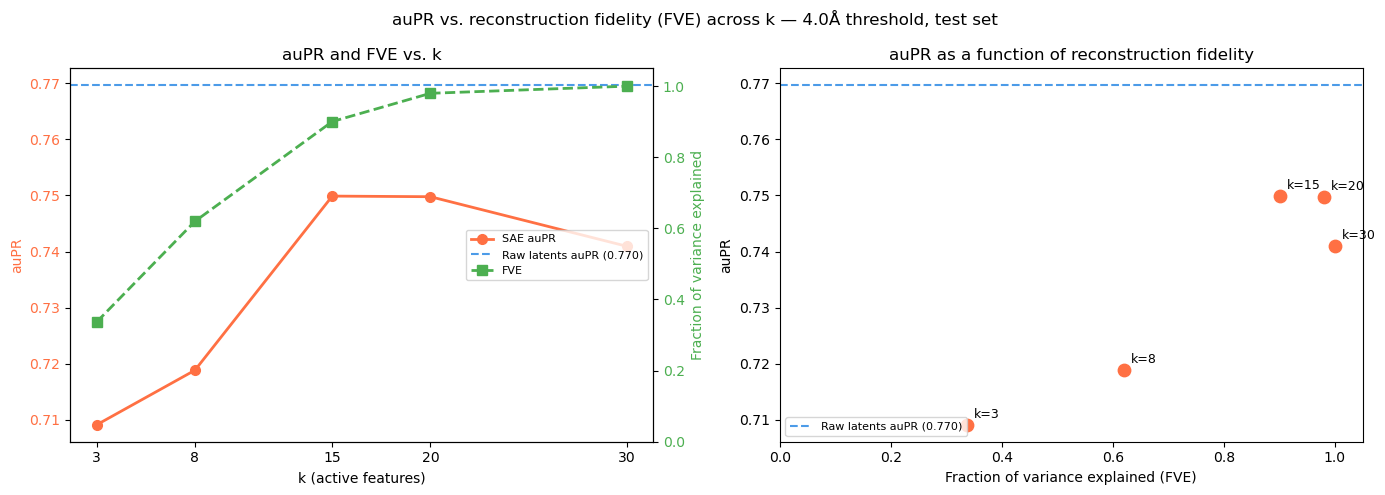

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/aupr_vs_fve.png

k         FVE      auPR
3       33.7%    0.7091
8       62.0%    0.7188
15      90.0%    0.7499
20      98.0%    0.7498
30     100.0%    0.7409

Raw latents auPR: 0.7697  (reference, not k-dependent)


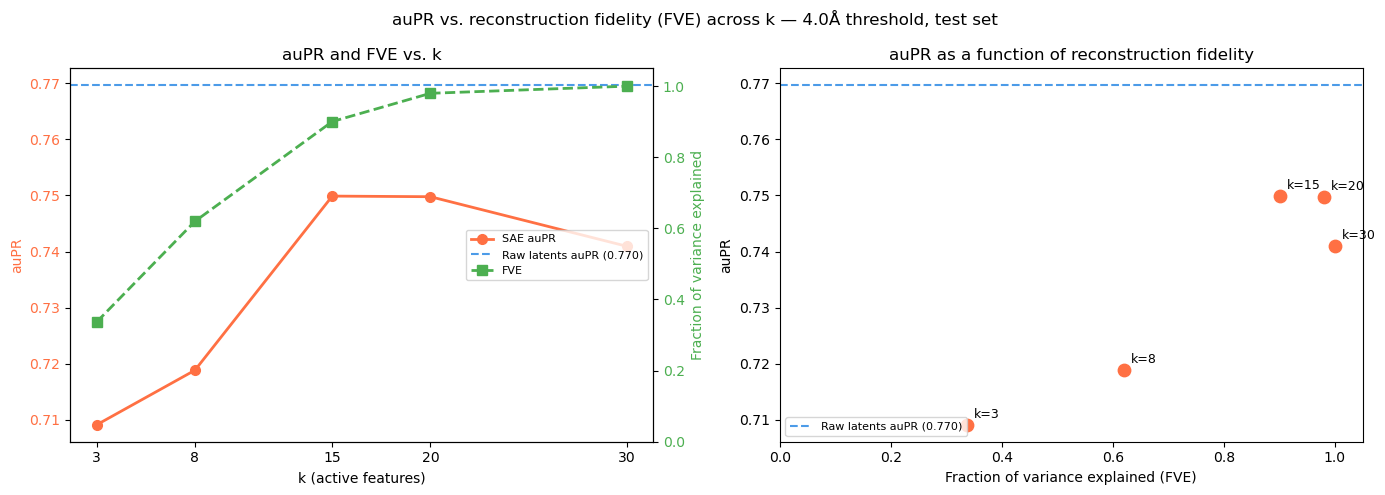

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/aupr_vs_fve.png

k         FVE      auPR
3       33.7%    0.7091
8       62.0%    0.7188
15      90.0%    0.7499
20      98.0%    0.7498
30     100.0%    0.7409

Raw latents auPR: 0.7697  (reference, not k-dependent)


In [20]:
# --- FVE (fraction of variance explained) per k, test set ---
# Complements auPR: measures whether the SAE preserves information in the latent
# space at all (reconstruction fidelity), independent of whether a downstream linear
# probe on the sparse code beats one on the dense original for THIS classification task.
print(f"\n{'='*70}")
print("Fraction of variance explained (FVE), test set")
print(f"{'='*70}")

var_x_test = X_raw_test.var(axis=0).sum()  # total variance across all 30 dims

fve_results = {}
for k in K_VALUES:
    model = trained_models[k]
    x_t = torch.tensor(X_raw_test, dtype=torch.float32, device=device)
    with torch.no_grad():
        recon = model.forward_val(x_t).cpu().numpy()
    sse_total = ((X_raw_test - recon) ** 2).mean(axis=0).sum()  # mean over samples, summed over dims -- same normalization as var_x_test
    fve = 1 - sse_total / var_x_test
    fve_results[k] = fve
    print(f"  k={k:<3}  FVE = {fve:.4f}  ({fve*100:.2f}% of variance explained)")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'auPR vs. reconstruction fidelity (FVE) across k — {RMSD_THRESHOLD}Å threshold, test set', fontsize=12)

aupr_by_k = {k: average_precision_score(y_test, clf_sae[k].predict_proba(features_test[k])[:, 1])
             for k in K_VALUES}
aupr_raw_ref = average_precision_score(y_test, prob_raw)
ks = K_VALUES
aupr_vals = [aupr_by_k[k] for k in ks]
fve_vals  = [fve_results[k] for k in ks]

ax = axes[0]
ax.plot(ks, aupr_vals, 'o-', color='#ff7043', label='SAE auPR', lw=2, markersize=7)
ax.axhline(aupr_raw_ref, color='#4c9be8', linestyle='--', lw=1.5,
           label=f'Raw latents auPR ({aupr_raw_ref:.3f})')
ax.set_xlabel('k (active features)')
ax.set_ylabel('auPR', color='#ff7043')
ax.tick_params(axis='y', labelcolor='#ff7043')
ax.set_xticks(ks)
ax2 = ax.twinx()
ax2.plot(ks, fve_vals, 's--', color='#4CAF50', label='FVE', lw=2, markersize=7)
ax2.set_ylabel('Fraction of variance explained', color='#4CAF50')
ax2.tick_params(axis='y', labelcolor='#4CAF50')
ax2.set_ylim(0, 1.05)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')
ax.set_title('auPR and FVE vs. k')

ax = axes[1]
ax.scatter(fve_vals, aupr_vals, s=80, color='#ff7043', zorder=3)
for k, x, y in zip(ks, fve_vals, aupr_vals):
    ax.annotate(f'k={k}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.axhline(aupr_raw_ref, color='#4c9be8', linestyle='--', lw=1.5,
           label=f'Raw latents auPR ({aupr_raw_ref:.3f})')
ax.set_xlabel('Fraction of variance explained (FVE)')
ax.set_ylabel('auPR')
ax.set_title('auPR as a function of reconstruction fidelity')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, 'aupr_vs_fve.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

print(f"\n{'k':<5}{'FVE':>8}{'auPR':>10}")
for k in ks:
    print(f"{k:<5}{fve_results[k]*100:>7.1f}%{aupr_by_k[k]:>10.4f}")
print(f"\nRaw latents auPR: {aupr_raw_ref:.4f}  (reference, not k-dependent)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'auPR vs. reconstruction fidelity (FVE) across k — {RMSD_THRESHOLD}Å threshold, test set', fontsize=12)

aupr_by_k = {k: average_precision_score(y_test, clf_sae[k].predict_proba(features_test[k])[:, 1])
             for k in K_VALUES}
aupr_raw_ref = average_precision_score(y_test, prob_raw)
ks = K_VALUES
aupr_vals = [aupr_by_k[k] for k in ks]
fve_vals  = [fve_results[k] for k in ks]

ax = axes[0]
ax.plot(ks, aupr_vals, 'o-', color='#ff7043', label='SAE auPR', lw=2, markersize=7)
ax.axhline(aupr_raw_ref, color='#4c9be8', linestyle='--', lw=1.5,
           label=f'Raw latents auPR ({aupr_raw_ref:.3f})')
ax.set_xlabel('k (active features)')
ax.set_ylabel('auPR', color='#ff7043')
ax.tick_params(axis='y', labelcolor='#ff7043')
ax.set_xticks(ks)
ax2 = ax.twinx()
ax2.plot(ks, fve_vals, 's--', color='#4CAF50', label='FVE', lw=2, markersize=7)
ax2.set_ylabel('Fraction of variance explained', color='#4CAF50')
ax2.tick_params(axis='y', labelcolor='#4CAF50')
ax2.set_ylim(0, 1.05)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')
ax.set_title('auPR and FVE vs. k')

ax = axes[1]
ax.scatter(fve_vals, aupr_vals, s=80, color='#ff7043', zorder=3)
for k, x, y in zip(ks, fve_vals, aupr_vals):
    ax.annotate(f'k={k}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.axhline(aupr_raw_ref, color='#4c9be8', linestyle='--', lw=1.5,
           label=f'Raw latents auPR ({aupr_raw_ref:.3f})')
ax.set_xlabel('Fraction of variance explained (FVE)')
ax.set_ylabel('auPR')
ax.set_title('auPR as a function of reconstruction fidelity')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, 'aupr_vs_fve.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

print(f"\n{'k':<5}{'FVE':>8}{'auPR':>10}")
for k in ks:
    print(f"{k:<5}{fve_results[k]*100:>7.1f}%{aupr_by_k[k]:>10.4f}")
print(f"\nRaw latents auPR: {aupr_raw_ref:.4f}  (reference, not k-dependent)")


### 10. Energy analysis

For each key SAE feature: what fraction of the poses it fires on have energy=10000 (BRAID sentinel for crashed/failed minimization), vs non-firing poses and the overall baseline?

In [21]:
SENTINEL = 10000.0  # BRAID sentinel for failed/unphysical minimization

k3_test     = features_test[3]          # (68614, 120) — SAE k=3 test activations
energy_test = metadata_test['energy'].values
good_test   = metadata_test['good_pose'].values  # 4Å label; energy analysis is label-agnostic

# Key features: (feature_idx, label, threshold_context)
KEY_FEATURES = [
    (70,  'feat 70 (4Å, prec=1.00)'),
    (107, 'feat 107 (4Å, prec=0.96)'),
    (39,  'feat 39 (2Å, thrombin rotation)'),
    (111, 'feat 111 (2Å, translation)'),
]

records = []
for feat, label in KEY_FEATURES:
    act     = k3_test[:, feat]
    firing  = act > 0
    e_fire  = energy_test[firing]
    e_rest  = energy_test[~firing]

    pct_sent_fire = (e_fire  >= SENTINEL).mean() * 100
    pct_sent_rest = (e_rest  >= SENTINEL).mean() * 100
    pct_sent_all  = (energy_test >= SENTINEL).mean() * 100

    e_fire_real = e_fire[e_fire < SENTINEL]
    e_rest_real = e_rest[e_rest < SENTINEL]

    records.append({
        'feat': feat, 'label': label,
        'n_fire': int(firing.sum()),
        'pct_sent_fire': pct_sent_fire,
        'pct_sent_rest': pct_sent_rest,
        'pct_sent_all':  pct_sent_all,
        'mean_e_fire': e_fire_real.mean() if len(e_fire_real) else float('nan'),
        'mean_e_rest': e_rest_real.mean() if len(e_rest_real) else float('nan'),
        'e_fire': e_fire, 'e_rest': e_rest,
        'e_fire_real': e_fire_real, 'e_rest_real': e_rest_real,
    })

    print(f"Feature {feat:>3}  [{label}]  n_firing={firing.sum():,}")
    print(f"  Firing poses:     {pct_sent_fire:5.1f}% sentinel  |  mean energy (non-sentinel) = {e_fire_real.mean() if len(e_fire_real) else float('nan'):,.0f}")
    print(f"  Non-firing poses: {pct_sent_rest:5.1f}% sentinel  |  mean energy (non-sentinel) = {e_rest_real.mean():,.0f}")
    print(f"  Baseline (all):   {pct_sent_all:5.1f}% sentinel")
    print()


Feature  70  [feat 70 (4Å, prec=1.00)]  n_firing=3,616
  Firing poses:      34.2% sentinel  |  mean energy (non-sentinel) = -11,999
  Non-firing poses:  38.6% sentinel  |  mean energy (non-sentinel) = -12,246
  Baseline (all):    38.4% sentinel

Feature 107  [feat 107 (4Å, prec=0.96)]  n_firing=422
  Firing poses:      31.5% sentinel  |  mean energy (non-sentinel) = -11,323
  Non-firing poses:  38.4% sentinel  |  mean energy (non-sentinel) = -12,239
  Baseline (all):    38.4% sentinel

Feature  39  [feat 39 (2Å, thrombin rotation)]  n_firing=8,081
  Firing poses:      31.1% sentinel  |  mean energy (non-sentinel) = -10,534
  Non-firing poses:  39.3% sentinel  |  mean energy (non-sentinel) = -12,490
  Baseline (all):    38.4% sentinel

Feature 111  [feat 111 (2Å, translation)]  n_firing=1
  Firing poses:       0.0% sentinel  |  mean energy (non-sentinel) = -10,578
  Non-firing poses:  38.4% sentinel  |  mean energy (non-sentinel) = -12,233
  Baseline (all):    38.4% sentinel



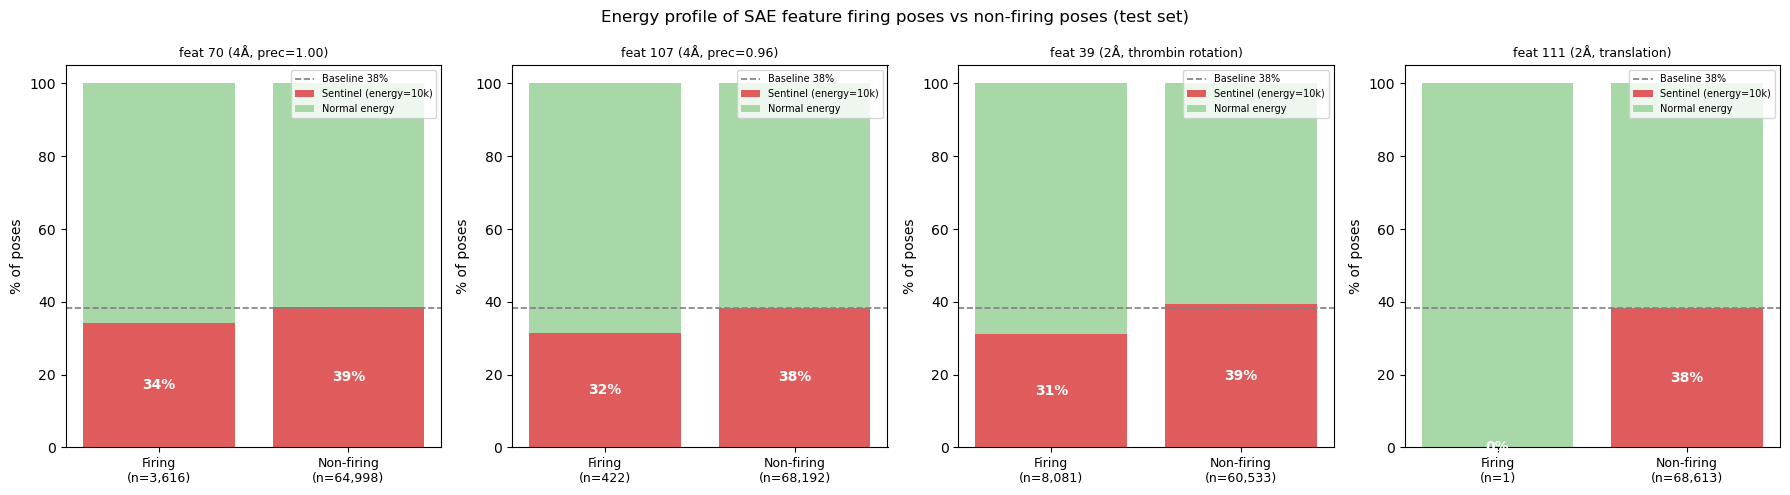

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/energy_analysis.png


In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Energy profile of SAE feature firing poses vs non-firing poses (test set)', fontsize=12)

for ax, rec in zip(axes, records):
    feat  = rec['feat']
    label = rec['label']

    # Stacked bar: sentinel vs real energy, for firing and non-firing
    cats   = ['Firing\n(n={:,})'.format(rec['n_fire']),
              'Non-firing\n(n={:,})'.format(len(energy_test) - rec['n_fire'])]
    sent   = [rec['pct_sent_fire'], rec['pct_sent_rest']]
    normal = [100 - s for s in sent]

    x = np.arange(2)
    b1 = ax.bar(x, sent,   color='#e05c5c', label='Sentinel (energy=10k)')
    b2 = ax.bar(x, normal, bottom=sent, color='#a8d8a8', label='Normal energy')

    for bar, val in zip(b1, sent):
        ax.text(bar.get_x() + bar.get_width()/2, val/2,
                f'{val:.0f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

    ax.axhline(rec['pct_sent_all'], color='grey', linestyle='--', lw=1.2,
               label=f'Baseline {rec["pct_sent_all"]:.0f}%')
    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_ylabel('% of poses')
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, 'energy_analysis.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


### 13. Baseline: BRAID energy-threshold filter (Reviewer 4ARp)

Reviewer 4ARp: the filtering results lack practical baselines — how much of the SAE
filter's performance is achievable by just thresholding on BRAID's own docking energy,
with no SAE at all? (DiffDock/KarmaDock-style confidence scores aren't applicable here —
different pipelines, and their training data likely isn't public — so this is scoped to
what's actually comparable: energy, already present in our own metadata.)

Same discipline as everywhere else in this notebook: sweep the threshold on TRAIN energy
only, apply once to TEST. Two comparisons:
1. **Best-F1 energy threshold** — single best operating point, analogous to the
   per-feature SAE thresholds in sections 11/12.
2. **Energy threshold matched to each SAE filter's flag rate** — the fairer test: at the
   *same* % of poses flagged as k=3/8/15's filters, does energy alone retain as many good
   poses / catch as many bad ones?

In [23]:
def sweep_energy_threshold(scores_train, scores_test, y_bad_train, y_bad_test,
                            lo, hi, n_thresholds=300):
    """Generic best-F1 threshold sweep (unlike threshold_stats, doesn't assume
    scores>=0 -- energy is signed and dominated by a huge sentinel spike)."""
    thresholds = np.linspace(lo, hi, n_thresholds)
    best_f1, best_thr = -1.0, None
    for thr in thresholds:
        flagged = scores_train >= thr
        if flagged.sum() < 10:
            continue
        prec = y_bad_train[flagged].mean()
        rec  = y_bad_train[flagged].sum() / y_bad_train.sum()
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    if best_thr is None:
        return None
    return eval_energy_threshold(scores_test, y_bad_test, best_thr)


def eval_energy_threshold(scores_test, y_bad_test, thr):
    flagged = scores_test >= thr
    if flagged.sum() == 0:
        return {'threshold': thr, 'precision': float('nan'), 'recall': float('nan'),
                'f1': float('nan'), 'n_flagged': 0, 'pct_flagged': 0.0, 'good_kept': 1.0}
    prec = y_bad_test[flagged].mean()
    rec  = y_bad_test[flagged].sum() / y_bad_test.sum()
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    good_kept = (~flagged)[y_bad_test == 0].mean()
    return {'threshold': thr, 'precision': prec, 'recall': rec, 'f1': f1,
            'n_flagged': int(flagged.sum()), 'pct_flagged': flagged.mean() * 100,
            'good_kept': good_kept}


# Sentinel (BRAID's crashed/unphysical-minimization flag) is 10000 or above -- values
# beyond that are the same "crashed" signal, just with pathological magnitudes, so the
# sweep only needs to cover [1st pct, sentinel]; thresholds above 10000 can't do better
# (same recall loss, no precision gain, since nothing distinguishes within the sentinel tail).
lo = np.percentile(energy_train, 1)
hi = 10000.0

# The sentinel value is a tied point mass: no energy threshold can flag fewer poses than
# the sentinel fraction itself, since every sentinel pose shares the same value and a
# threshold either includes all of them or none. This sets a hard *minimum* achievable
# flag rate for ANY energy-threshold filter -- below this floor, energy simply cannot
# match a target flag rate, no matter how the threshold is tuned.
sentinel_floor_pct = (energy_test >= hi).mean() * 100

print(f"Energy sweep range: [{lo:,.0f}, {hi:,.0f}]")
print(f"Baseline bad-pose rate (test): {baseline_bad:.3f}")
print(f"Energy sentinel floor (test): {sentinel_floor_pct:.1f}% of poses tied at energy=10000 "
      f"-- no energy threshold can flag fewer poses than this\n")

# 1. Best-F1 energy threshold
best_energy = sweep_energy_threshold(energy_train, energy_test, y_train, y_bad_test, lo, hi)
print("=== Best-F1 energy-threshold filter ===")
print(f"  threshold={best_energy['threshold']:,.0f}  pct_flagged={best_energy['pct_flagged']:.1f}%  "
      f"precision={best_energy['precision']:.3f}  recall={best_energy['recall']:.3f}  "
      f"good_kept={best_energy['good_kept']*100:.1f}%")

# 2. Energy threshold matched to each SAE filter's flag rate (percentile-matched on TRAIN),
# when that flag rate is actually achievable (i.e. at or above the sentinel floor). Below
# the floor there is no valid comparison point -- report that explicitly instead of
# silently returning the floor's stats as if they were "matched" (they aren't: a lower
# target flag rate than the floor cannot be realized by any energy threshold).
# Pull the TEST %flagged achieved by each k's pooled-train+val-selected filter (sections
# 11/12) -- combo identity was chosen without touching test, this is its one-shot test
# result, so matching against it here stays apples-to-apples (test-vs-test).
sae_pct_flagged = {
    3:  targeted_test_result[3]['pct_flagged'],
    8:  targeted_test_result[8]['pct_flagged'],
    15: targeted_test_result[15]['pct_flagged'],
}

# Energy's own best-case operating point in the sub-floor regime: the sentinel-only
# filter (threshold = 10000, i.e. flag exactly the tied sentinel mass and nothing else).
# This is the *most conservative* filter energy can produce -- useful as the honest
# reference point for any SAE operating point below the floor, since energy cannot be
# made any more conservative than this.
sentinel_only = eval_energy_threshold(energy_test, y_bad_test, hi)

print("\n=== Energy vs. SAE filter, per k ===")
print(f"{'k':<4}{'SAE %flag':>10}{'SAE prec':>10}{'SAE good_kept':>15}"
      f"{'  energy %flag':>15}{'energy prec':>13}{'energy good_kept':>18}")
for k, target_pct in sae_pct_flagged.items():
    sae_prec      = targeted_test_result[k]['precision']
    sae_good_kept = targeted_test_result[k]['good_kept'] * 100
    if target_pct < sentinel_floor_pct:
        # Not achievable -- energy's floor (sentinel-only filter) is the closest/most
        # conservative reference point it can offer, but it still flags MORE poses than
        # the SAE filter at worse or comparable good_kept, so it's already dominated.
        print(f"{k:<4}{target_pct:>10.1f}{sae_prec:>10.3f}{sae_good_kept:>15.1f}"
              f"{'  N/A (< floor)':>15}{sentinel_only['precision']:>13.3f}"
              f"{sentinel_only['good_kept']*100:>18.1f}")
        print(f"     -> energy cannot flag fewer than {sentinel_floor_pct:.1f}% of poses "
              f"(sentinel tied-mass floor); SAE flags {target_pct:.1f}% at "
              f"{sae_good_kept:.1f}% good_kept, which is structurally out of energy's reach.")
    else:
        thr = np.percentile(energy_train, 100 - target_pct)
        r = eval_energy_threshold(energy_test, y_bad_test, thr)
        print(f"{k:<4}{target_pct:>10.1f}{sae_prec:>10.3f}{sae_good_kept:>15.1f}"
              f"{r['pct_flagged']:>15.1f}{r['precision']:>13.3f}{r['good_kept']*100:>18.1f}")


Energy sweep range: [-25,285, 10,000]
Baseline bad-pose rate (test): 0.634
Energy sentinel floor (test): 38.4% of poses tied at energy=10000 -- no energy threshold can flag fewer poses than this



=== Best-F1 energy-threshold filter ===
  threshold=-25,285  pct_flagged=100.0%  precision=0.634  recall=1.000  good_kept=0.0%

=== Energy vs. SAE filter, per k ===
k    SAE %flag  SAE prec  SAE good_kept   energy %flag  energy prec  energy good_kept
3         27.3     0.698           77.5  N/A (< floor)        0.799              78.9
     -> energy cannot flag fewer than 38.4% of poses (sentinel tied-mass floor); SAE flags 27.3% at 77.5% good_kept, which is structurally out of energy's reach.
8         16.5     0.803           91.1  N/A (< floor)        0.799              78.9
     -> energy cannot flag fewer than 38.4% of poses (sentinel tied-mass floor); SAE flags 16.5% at 91.1% good_kept, which is structurally out of energy's reach.
15        12.3     0.879           95.9  N/A (< floor)        0.799              78.9
     -> energy cannot flag fewer than 38.4% of poses (sentinel tied-mass floor); SAE flags 12.3% at 95.9% good_kept, which is structurally out of energy's reach.


### 14. Sentinel-rate + dominant-case breakdown for the k=8 headline combo candidates

For each of the 16 pooled-train+val-selected candidate features that make up the k=8 headline filter (Section 12), computed on the held-out test set: the sentinel (crashed-minimization) rate of poses it fires on vs. doesn't fire on vs. the population baseline (same lens as the old Section 10 energy analysis, but applied to the current candidate features instead of the stale pre-retrain indices 70/107/39/111), plus the top-5 `case_id`s by count among its flagged poses. Sorted by firing-sentinel-rate descending, so the catastrophic-failure (high sentinel) and geometric-failure (baseline sentinel) detectors separate out the same way features 39/111 vs. 70/107 did in the original paper.


In [24]:
SENTINEL = 10000.0
K_SPOTLIGHT = 8

acts_k       = features_test[K_SPOTLIGHT]
thresholds_k = targeted_thresholds[K_SPOTLIGHT]
winning_k    = set(targeted_winning_combo[K_SPOTLIGHT])
pct_sent_all = (energy_test >= SENTINEL).mean() * 100

case_breakdown_records = []
case_breakdown_top5    = {}
for feat, thr in thresholds_k.items():
    firing = acts_k[:, feat] >= thr
    e_fire = energy_test[firing]
    e_rest = energy_test[~firing]
    precision = y_bad_test[firing].mean() if firing.sum() > 0 else float('nan')
    pct_sent_fire = (e_fire >= SENTINEL).mean() * 100 if firing.sum() > 0 else float('nan')
    pct_sent_rest = (e_rest >= SENTINEL).mean() * 100 if (~firing).sum() > 0 else float('nan')
    top_cases = metadata_test.loc[firing, 'case_id'].value_counts().head(5)
    case_breakdown_top5[feat] = top_cases
    case_breakdown_records.append({
        'feature': feat, 'in_winning_combo': feat in winning_k,
        'threshold': thr, 'n_firing': int(firing.sum()),
        'pct_flagged': firing.mean() * 100, 'precision': precision,
        'pct_sentinel_firing': pct_sent_fire, 'pct_sentinel_nonfiring': pct_sent_rest,
        'pct_sentinel_baseline': pct_sent_all,
        'top_case': top_cases.index[0] if len(top_cases) else None,
        'top_case_n': int(top_cases.iloc[0]) if len(top_cases) else 0,
    })

case_breakdown_df = (pd.DataFrame(case_breakdown_records)
                      .sort_values('pct_sentinel_firing', ascending=False)
                      .reset_index(drop=True))
print(f"k={K_SPOTLIGHT} candidate features, sorted by sentinel rate on firing poses "
      f"(population baseline: {pct_sent_all:.1f}% sentinel)")
print(case_breakdown_df.to_string(index=False, float_format='{:.3f}'.format))

print(f"\nWinning combo for k={K_SPOTLIGHT}: {sorted(winning_k)}\n")
for feat in case_breakdown_df['feature']:
    top_cases = case_breakdown_top5[feat]
    in_combo = '*' if feat in winning_k else ' '
    print(f"[{in_combo}] Feature {feat}: top-5 cases by firing-pose count -- "
          + ', '.join(f'{c} ({n})' for c, n in top_cases.items()))


k=8 candidate features, sorted by sentinel rate on firing poses (population baseline: 38.4% sentinel)
 feature  in_winning_combo  threshold  n_firing  pct_flagged  precision  pct_sentinel_firing  pct_sentinel_nonfiring  pct_sentinel_baseline              top_case  top_case_n
      51              True      0.034       711        1.036      0.809               86.357                  37.851                 38.354 throm_1ae8_throm_1d9i         706
      28              True      0.037        25        0.036      0.720               60.000                  38.346                 38.354 glur5_3fv1_glur5_3fuz          19
      50              True      0.020       360        0.525      0.742               57.778                  38.251                 38.354 throm_1ae8_throm_1d9i         151
      71              True      0.040      1718        2.504      0.574               56.810                  37.880                 38.354 throm_1ae8_throm_1d9i         850
      12              True  

### 15. Activation distributions for the spotlight features (51, 84)

Activation distribution (active poses only, raw count, log-scale), split by the **2Å native-pose criterion** (RMSD <= 2Å = good), for the two features spotlighted in the paper's Interpretable Features section. Two things changed from the first version of this cell: (1) switched from the 4Å label to the 2Å label -- both features turn out to be dramatically cleaner against the stricter, more standard native-pose definition (feat 51: 0.809->1.000 precision, 0 false positives at all; feat 84: 0.911->0.975); (2) switched from `density=True` to raw counts, since normalizing 21 false positives to the same visual area as 806 true positives was misleading -- raw counts correctly show the false positives as small, sparse bars under the bad-pose mass.


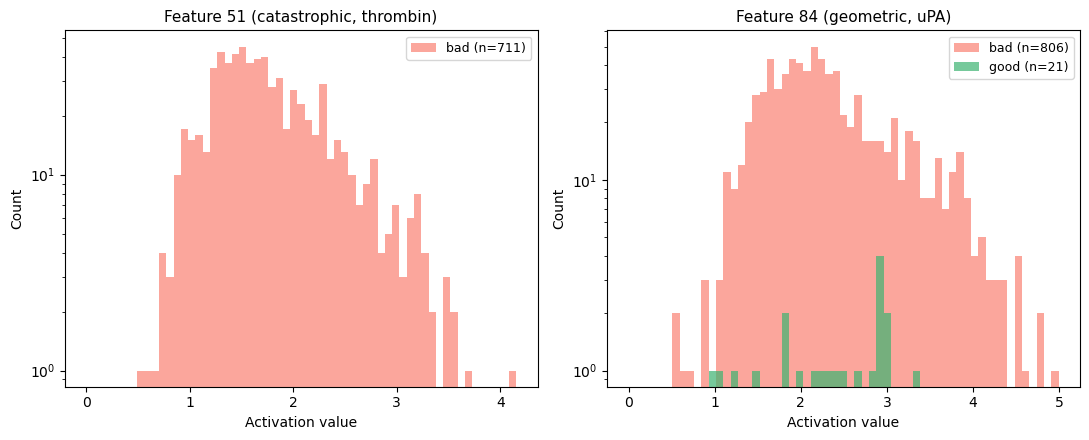

Saved: /Users/bridget/Desktop/projects/laloo-sae/output/4A/feature_51_84_activation_dist.png


In [25]:
SPOTLIGHT_FEATURES = [(51, 'Feature 51 (catastrophic, thrombin)'),
                       (84, 'Feature 84 (geometric, uPA)')]
good_mask_2A = (metadata_test['rmsd'].values <= 2.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (feat, title) in zip(axes, SPOTLIGHT_FEATURES):
    a = features_test[8][:, feat]
    active = a > 0
    a_act = a[active]
    y_act = good_mask_2A[active]
    bins = np.linspace(0, a_act.max() if len(a_act) else 1.0, 60)
    ax.hist(a_act[~y_act], bins=bins, density=False, alpha=0.7, color='salmon',
            label=f'bad (n={(~y_act).sum():,})')
    if y_act.sum() > 0:
        ax.hist(a_act[y_act], bins=bins, density=False, alpha=0.7, color='mediumseagreen',
                label=f'good (n={y_act.sum():,})')
    ax.set_yscale('log')
    ax.set_xlabel('Activation value')
    ax.set_ylabel('Count')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, 'feature_51_84_activation_dist.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')
